In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

In [2]:
def getfiles(base):
    files = os.listdir(base)
    full_files = [base+f for f in files if 'Base.csv' in f]
    #full_files = [base+f for f in files if 'EpcLog' not in f]
    print(len(full_files))
    return full_files

def getlcfiles(base):
    files = os.listdir(base)
    files = [f for f in files if '.csv' in f]
    full_files = [base+f for f in files if 'EpcLog' in f]
    return full_files
    

def geterror(base):
    full_files = getfiles(base)
    num_models = len(full_files)
    p = Precision()
    L1_means = np.zeros(num_models)
    L1_vars = np.zeros(num_models)
    for f in range(len(full_files)):
        err_model = p.mult_models([full_files[f]])
        L1 = np.abs(err_model)
        L1_means[f]=np.mean(L1)
        L1_vars[f] = np.var(L1)
    #mse = np.sqrt(np.mean(err**2)) 
    total_mean = np.mean(L1_means)
    total_var = np.mean(L1_vars)/num_models
    errorbar_std = np.std(L1_means)/np.sqrt(num_models)
    return err_model, total_mean, total_var, errorbar_std
    
def getlc(base):
    full_files = getlcfiles(base)
    num_models = len(full_files)
    SSE=[]
    Epoch = []
    for f in full_files:
        if 'model0_' in f:
            df = pd.read_csv(f, sep = '\t')
            SSE.append(df['#SSE'])
            Epoch.append(df['|Epoch'])
        else:
            df = pd.read_csv(f,sep = '\t', header = None)
            SSE.append(df[2])
    SSE_np = np.array(SSE)
    SSE_avg = np.mean(SSE_np, axis = 0)
    SSE_std = np.std(SSE_np, axis = 0)/np.sqrt(num_models)
    #plt.plot(Epoch[0],SSE_avg)
    
    return Epoch[0], SSE_avg, SSE_std 
    

def geterror_array(base):
    full_files = getfiles(base)
    p = Precision()
    err = p.mult_models(full_files)
    return err

def plot_title(base):
    
    if 'contexp' in base:
        rewardtype = 'Continuous Exponential'
    elif 'RewThresh' in base:
        rewardtype = 'Binary'
    else:
        rewardtype = 'Continuous Linear'
        
    if 'decodedrew' in base:
        rewardfun = 'Decoded'
    else: 
        rewardfun = 'Unit Difference'
        
    if 'NoStimLoc' in base:
        stimloc = ', No Stim Loc'
    else: 
        stimloc = ", Stim Loc Used"
   
    if 'NoIgnore' in base:
        ignore = ', No Ignore Trials'
    else:
        ignore = ''

    if "StimRange0to45" in base:
        stim_dist = ', StimDist Max 45'
    else:
        stim_dist = ""


    title = 'Reward Function: ' + rewardtype +', ' +rewardfun +stimloc + ignore +stim_dist#+' '+additional_title
    return title

def find_a(var, J, n):
    a = math.log(1/(var*J), Base = n)  
    return a


def burstdip_allmodels(base,base2,experiment, burst, dip, plot_errorbars = True):

    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    sir4_file = base + "sir4/" +base2+experiment
    sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment

    err_sir2, mse_sir2, var_sir2, std_sir2 = geterror(sir2_file)
    err_sir2_chunk, mse_sir2_chunk, var_sir2_chunk,std_sir2_chunk = geterror(sir2_chunk_file)
    err_sir3, mse_sir3, var_sir3,std_sir3 = geterror(sir3_file)
    err_sir3_chunk, mse_sir3_chunk, var_sir3_chunk,std_sir3_chunk = geterror(sir3_chunk_file)
    err_sir4, mse_sir4, var_sir4,std_sir4 = geterror(sir4_file)
    err_sir4_chunk, mse_sir4_chunk, var_sir4_chunk,std_sir4_chunk = geterror(sir4_chunk_file)
    
    plt.figure()
    title = "Burst: {}, Dip: {}".format(burst,dip)
    tasks = [2,3,4]
    mse_all_nochunk = [mse_sir2,mse_sir3,mse_sir4]
    std_all_nochunk = [std_sir2,std_sir3, std_sir4]

    mse_all_chunk = [mse_sir2_chunk,mse_sir3_chunk,mse_sir4_chunk]
    std_all_chunk = [std_sir2_chunk,std_sir3_chunk,std_sir4_chunk]

    plt.xlim(1.8,4.2)
    if plot_errorbars == True:
        plt.errorbar(tasks,mse_all_nochunk,std_all_nochunk)
        plt.errorbar(tasks,mse_all_chunk, std_all_chunk)
    else:
        plt.plot(tasks,mse_all_nochunk)
        plt.plot(tasks,mse_all_chunk)
    plt.xticks(tasks)
    plt.ylabel('Absolute Error Averaged over Models')
    #plt.ylabel(r'$\sqrt{MSE}$')
    plt.xlabel('Number of Items')
    plt.legend(['No Chunk', 'Chunk'], loc = 'lower right')
    plt.title(title)


def mse_allmodels(base, base2, experiment, plot_errorbars = True, sir4 = False):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    
    if sir4:
        sir4_file = base + "sir4/" +base2+experiment
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
    
    err_sir2, mse_sir2, var_sir2, std_sir2 = geterror(sir2_file)
    err_sir2_chunk, mse_sir2_chunk, var_sir2_chunk,std_sir2_chunk = geterror(sir2_chunk_file)
    err_sir3, mse_sir3, var_sir3,std_sir3 = geterror(sir3_file)
    err_sir3_chunk, mse_sir3_chunk, var_sir3_chunk,std_sir3_chunk = geterror(sir3_chunk_file)
    err_sir4, mse_sir4, var_sir4,std_sir4 = geterror(sir4_file)
    err_sir4_chunk, mse_sir4_chunk, var_sir4_chunk,std_sir4_chunk = geterror(sir4_chunk_file)
    
#   a2 = find_a(1-err_sir2,)
#     a2_chunk = find_a(1-err_sir2_chunk,)
#     a3 = find_a(1-err_sir3)
#     title = plot_title(sir2_file)
#     title = title+"/n a values for sir2: {:.2f}, sir3: {:.2f}, sir2_chunk: {:.2f}, sir3_chunk {:.2f}".format(a2, a3, a2_chunk, a3_chunk)

    title = plot_title(sir2_file)
    if sir4:
        tasks = [2,3,4]
        mse_all_nochunk = [mse_sir2,mse_sir3,mse_sir4]
        std_all_nochunk = [std_sir2,std_sir3, std_sir4]
        
        mse_all_chunk = [mse_sir2_chunk,mse_sir3_chunk,mse_sir4_chunk]
        std_all_chunk = [std_sir2_chunk,std_sir3_chunk,std_sir4_chunk]
        
        plt.xlim(1.8,4.2)
    else:
        tasks = [2,3]
        mse_all_nochunk = [mse_sir2,mse_sir3]
        std_all_nochunk = [std_sir2,std_sir3]
        
        mse_all_chunk = [mse_sir2_chunk,mse_sir3_chunk]
        std_all_chunk = [std_sir2_chunk,std_sir3_chunk]
   
        plt.xlim([1.8,3.2])
    
    if plot_errorbars == True:
        plt.errorbar(tasks,mse_all_nochunk,std_all_nochunk)
        plt.errorbar(tasks,mse_all_chunk, std_all_chunk)
    else:
        plt.plot(tasks,mse_all_nochunk)
        plt.plot(tasks,mse_all_chunk)

#         if plot_errorbars == True:
#             plt.errorbar([2,3],[mse_sir2,mse_sir3], [std_sir2,std_sir3])
#             plt.errorbar([2,3],[mse_sir2_chunk,mse_sir3_chunk], [std_sir2_chunk,std_sir3_chunk])
#         else:
#             plt.plot([2,3],[mse_sir2,mse_sir3])
#             plt.plot([2,3],[mse_sir2_chunk,mse_sir3_chunk])
#         plt.xticks([2,3])
#         plt.xlim([1.8,3.2])
        
    plt.xticks(tasks)
    plt.ylabel('Absolute Error Averaged over Models')
    #plt.ylabel(r'$\sqrt{MSE}$')
    plt.xlabel('Number of Items')
    plt.legend(['No Chunk', 'Chunk'], loc = 'lower right')
    plt.title(title)
    
    plt.figure()
    #percent imrpovement for chunk model over the no chunk model. 
    task2 = (np.abs(mse_sir2-mse_sir2_chunk)/mse_sir2)*100
    task3 = (np.abs(mse_sir3-mse_sir3_chunk)/mse_sir3)*100
    plt.bar(['Task 2', 'Task 3'], [task2, task3])
    
def lc_allmodels(base,base2,experiment, plot_errorbars = True, sir4 = False):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    if sir4:
        sir4_file = base + "sir4/" +base2+experiment
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
    
    _, SSE_sir2, std_sir2 = getlc(sir2_file)
    _, SSE_sir2_chunk, std_sir2_chunk = getlc(sir2_chunk_file)
    _, SSE_sir3, std_sir3 = getlc(sir3_file)
    Epoch, SSE_sir3_chunk, std_sir3_chunk = getlc(sir3_chunk_file)
    if sir4:
        _, SSE_sir4, std_sir4 = getlc(sir4_file)
        _, SSE_sir4_chunk, std_sir4_chunk = getlc(sir4_chunk_file)
    
    title = plot_title(sir2_file)
    plt.figure()
    if plot_errorbars:
        plt.errorbar(Epoch,SSE_sir2,std_sir2)
        plt.errorbar(Epoch,SSE_sir2_chunk, std_sir2_chunk)

    else:
        plt.plot(Epoch,SSE_sir2)
        plt.plot(Epoch,SSE_sir2_chunk)
    
    plt.title(title+ ', SIR 2 Task')
    plt.xlabel('Epoch')
    plt.ylabel('SSE')
    plt.legend(['No Chunk', 'Chunk'])
    
    plt.figure()
    if plot_errorbars:
        plt.errorbar(Epoch,SSE_sir3, std_sir3)
        plt.errorbar(Epoch,SSE_sir3_chunk, std_sir3_chunk)
    else:
        plt.plot(Epoch,SSE_sir3)
        plt.plot(Epoch,SSE_sir3_chunk)
        
    plt.title(title+ ', SIR 3 Task')
    plt.xlabel('Epoch')
    plt.ylabel('SSE')
    plt.legend(['No Chunk', 'Chunk'])
    
    if sir4:
        plt.figure()
        if plot_errorbars:
            plt.errorbar(Epoch,SSE_sir4, std_sir4)
            plt.errorbar(Epoch,SSE_sir4_chunk, std_sir4_chunk)
        else:
            plt.plot(Epoch,SSE_sir4)
            plt.plot(Epoch,SSE_sir4_chunk)

        plt.title(title+ ', SIR 4 Task')
        plt.xlabel('Epoch')
        plt.ylabel('SSE')
        plt.legend(['No Chunk', 'Chunk'])

def plot_allhist(base,base2,experiment,sir4 = False):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    
    if sir4:
        sir4_file = base + "sir4/" +base2+experiment
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
        
    
    title = plot_title(sir2_file)
    err = geterror_array(sir2_file)
    plt.figure()
    plt.hist(err, bins = 50)
    plt.title("Task 2, No Chunk, "+title)
    
    err = geterror_array(sir2_chunk_file)
    plt.figure()
    plt.hist(err, bins = 50)
    plt.title("Task 2, Chunk, "+title)
    
    err = geterror_array(sir3_file)
    plt.figure()
    plt.hist(err, bins = 50)
    plt.title("Task 3, No Chunk, "+title)
    
    err = geterror_array(sir3_chunk_file)
    plt.figure()
    plt.hist(err, bins = 50)
    plt.title("Task 3, Chunk, "+title)
    
    if sir4:
    
        err = geterror_array(sir4_file)
        plt.figure()
        plt.hist(err, bins = 50)
        plt.title("Task 3, No Chunk, "+title)

        err = geterror_array(sir4_chunk_file)
        plt.figure()
        plt.hist(err, bins = 50)
        plt.title("Task 4, Chunk, "+title)
    
    

def plot_var(base,base2,experiment, sir4 = False, pretrain = True):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    if sir4:
        sir4_file = base + "sir4/" +base2+experiment
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
    
    err_sir2, mse_sir2, var_sir2, std_sir2 = geterror(sir2_file)
    err_sir2_chunk, mse_sir2_chunk, var_sir2_chunk,std_sir2_chunk = geterror(sir2_chunk_file)
    err_sir3, mse_sir3, var_sir3,std_sir3 = geterror(sir3_file)
    err_sir3_chunk, mse_sir3_chunk, var_sir3_chunk,std_sir3_chunk = geterror(sir3_chunk_file)
    if sir4:
        err_sir4, mse_sir4, var_sir4,std_sir4 = geterror(sir4_file)
        err_sir4_chunk, mse_sir4_chunk, var_sir4_chunk,std_sir4_chunk = geterror(sir4_chunk_file)
        mod = ["SIR 2, No Chunk", "SIR 2, Chunk", "SIR 3, No Chunk", "SIR 3 Chunk", "SIR 4, No Chunk", "SIR 4, Chunk"]
        var = [var_sir2,var_sir2_chunk,var_sir3,var_sir3_chunk,var_sir4,var_sir4_chunk]
    else:
        mod = ["SIR 2, No Chunk", "SIR 2, Chunk", "SIR 3, No Chunk", "SIR 3 Chunk"]
        var = [var_sir2,var_sir2_chunk,var_sir3,var_sir3_chunk]
    
    plt.bar(mod,var)
    plt.xlabel('Model Type')
    plt.ylabel('Average Variance in Model')


# def plot_allhist_recalltype(base,base2,experiment)
#     sir2_file = base + "sir2_new/" +base2+experiment
#     sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
#     sir3_file = base + "sir3/" +base2+experiment
#     sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    
    
        
#     for f in full_files:
#         err = Precision()
#         recall1,recall2,recall3=err.err_recall_type_sir3(f)
#         plt.figure()
#         model = f.split('/')[-1].split('_Stripes')[0]
#         plt.hist(recall1)
#         plt.title('Recall 1 Errors ,' +model)
#         plt.figure()
#         plt.hist(recall2)
#         plt.title('Recall 2 Errors ,'+model)
#         plt.figure()
#         plt.hist(recall3)
#         plt.title('Recall 3 Errors ,'+model)
#     return full_files


def burstdip_allstimdist(base,base2,experiment, burst, dip, plot_errorbars = True, tasks = []):
        
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    sir4_file = base + "sir4/" +base2+experiment
    sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment

    err_sir2, mse_sir2, var_sir2, std_sir2 = geterror(sir2_file)
    err_sir2_chunk, mse_sir2_chunk, var_sir2_chunk,std_sir2_chunk = geterror(sir2_chunk_file)
    err_sir3, mse_sir3, var_sir3,std_sir3 = geterror(sir3_file)
    err_sir3_chunk, mse_sir3_chunk, var_sir3_chunk,std_sir3_chunk = geterror(sir3_chunk_file)
    err_sir4, mse_sir4, var_sir4,std_sir4 = geterror(sir4_file)
    err_sir4_chunk, mse_sir4_chunk, var_sir4_chunk,std_sir4_chunk = geterror(sir4_chunk_file)
    
    plt.figure()
    title = "Burst: {}, Dip: {}".format(burst,dip)
    tasks = [2,3,4]
    mse_all_nochunk = [mse_sir2,mse_sir3,mse_sir4]
    std_all_nochunk = [std_sir2,std_sir3, std_sir4]

    mse_all_chunk = [mse_sir2_chunk,mse_sir3_chunk,mse_sir4_chunk]
    std_all_chunk = [std_sir2_chunk,std_sir3_chunk,std_sir4_chunk]

    plt.xlim(1.8,4.2)
    if plot_errorbars == True:
        plt.errorbar(tasks,mse_all_nochunk,std_all_nochunk)
        plt.errorbar(tasks,mse_all_chunk, std_all_chunk)
    else:
        plt.plot(tasks,mse_all_nochunk)
        plt.plot(tasks,mse_all_chunk)
    plt.xticks(tasks)
    plt.ylabel('Absolute Error Averaged over Models')
    #plt.ylabel(r'$\sqrt{MSE}$')
    plt.xlabel('Number of Items')
    plt.legend(['No Chunk', 'Chunk'], loc = 'lower right')
    plt.title(title)

def burstdipLC(base,base2,experiment,burst, dip):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    sir4_file = base + "sir4/" +base2+experiment
    sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
    title = ", Burst: {}, Dip: {}".format(burst,dip)
    plt.figure()
    SSE_avg, Epoch = training_curve_average(sir2_file, additional_title =title)
    
    plt.figure()
    SSE_avg, Epoch = training_curve_average(sir2_chunk_file, additional_title =title)
    
    plt.figure()
    SSE_avg, Epoch = training_curve_average(sir3_file, additional_title =title)
    
    plt.figure()
    SSE_avg, Epoch = training_curve_average(sir3_chunk_file, additional_title = title)
    
    plt.figure()
    SSE_avg, Epoch = training_curve_average(sir4_file, additional_title =title)
    
    plt.figure()
    SSE_avg, Epoch = training_curve_average(sir4_chunk_file, additional_title = title)
    plt.show()

def burstdip_indlc(base,BurstName,DipName, last_epoch = False):
    leg = []
    if last_epoch:
        last_epoch_SSE = []
    for burst in range(len(BurstName)):
        for dip in range(len(DipName)):
            gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
            SSE_avg, Epoch = training_curve_average(base+gain, plot = False)
            plt.plot(Epoch[0], SSE_avg)
            leg.append(gain.replace('/', ' '))
            if last_epoch:
                last_epoch_SSE.append(SSE_avg[-1])
    plt.legend(leg)
    plt.show()
    if last_epoch:
        return last_epoch_SSE
    
def burstdip_lastepoch(base,BurstName,DipName,last_epoch = True, errorbars = True):
    last_epoch_SSE_avg = []
    last_epoch_std = []
    for burst in range(len(BurstName)):
        for dip in range(len(DipName)):
            gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
            last_epoch_SSE  = training_curve_indv(base+gain, last_epoch = True, plot = False)
            last_epoch_SSE_avg.append(np.mean(last_epoch_SSE))
            last_epoch_std.append(np.std(last_epoch_SSE))
    return last_epoch_SSE_avg,last_epoch_std

def burstdip_mse(base,BurstName,Dipname,errorbars = True, add_folder = ''):
    SSE_avg = []
    SSE_std = []
    for burst in range(len(BurstName)):
        for dip in range(len(DipName)):
            gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"+add_folder
            #p = Precision()
            #full_files=(getfiles(base+gain))
            #err = p.mult_models(full_files)
            err_model, total_mean, total_var, errorbar_std = geterror(base+gain)
            SSE_avg.append(total_mean)
            SSE_std.append(errorbar_std)
    return SSE_avg,SSE_std
            

80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80


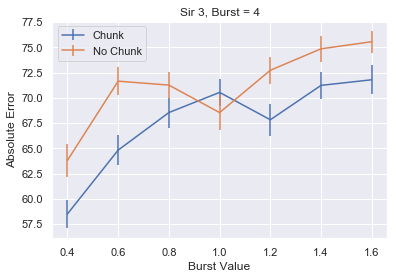

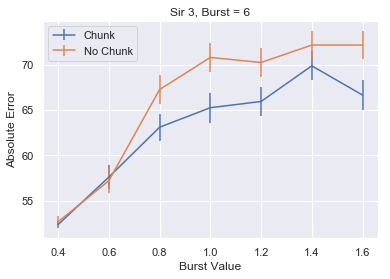

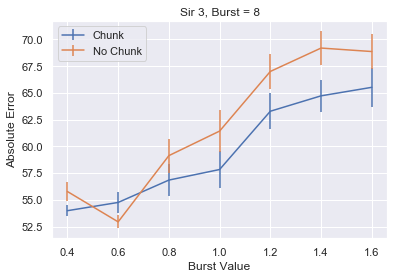

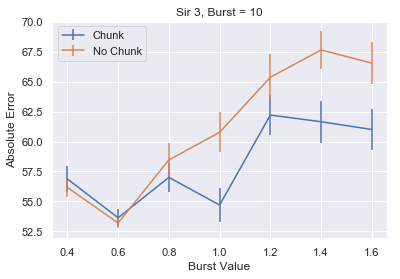

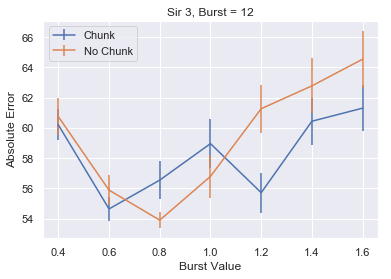

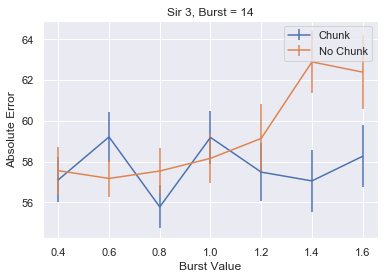

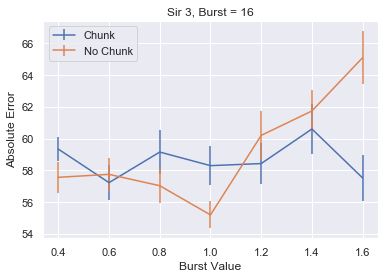

In [3]:
#10/17/2023
SSE_total= []
SSE_nochunk_total= []

BurstName = ["4"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["6"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["8"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["10"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["12"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["14"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


In [4]:
np.save("sir3_nohiddennostimloclrate06_chunk_ABE", np.array(SSE_total))
np.save("sir3_nohiddennostimloclrate06_nochunk_ABE", np.array(SSE_nochunk_total))

80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 2, Dip = 16')

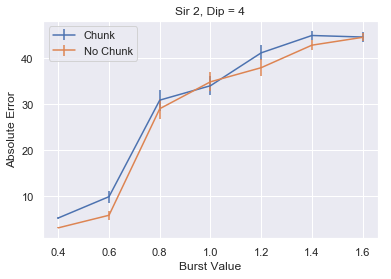

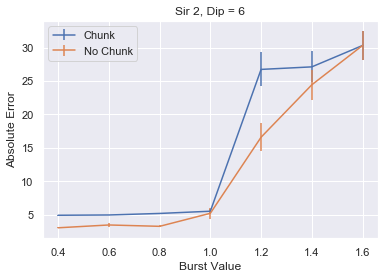

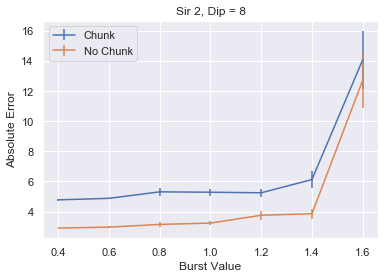

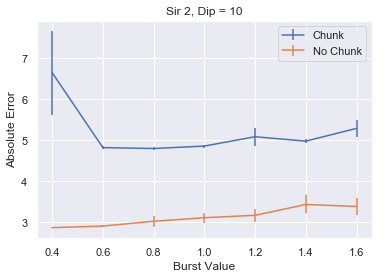

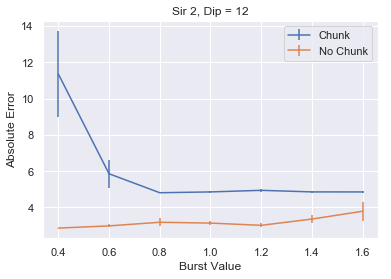

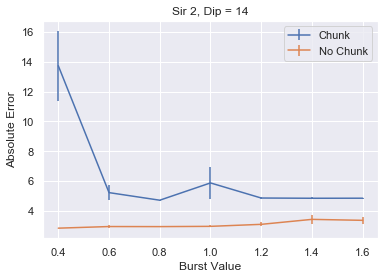

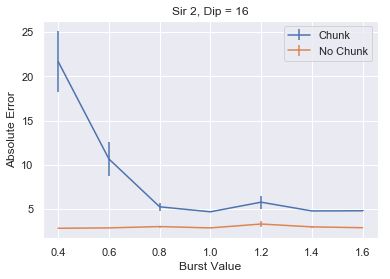

In [13]:

DipName = ["4"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["6"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["8"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["10"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["12"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


DipName = ["14"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


DipName = ["16"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 3, Dip = 16')

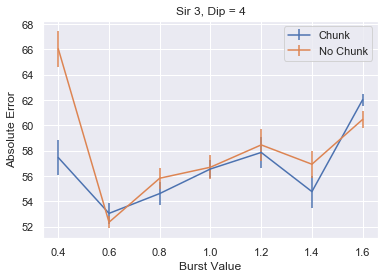

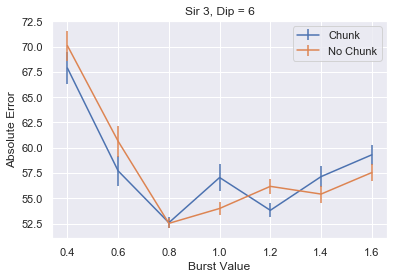

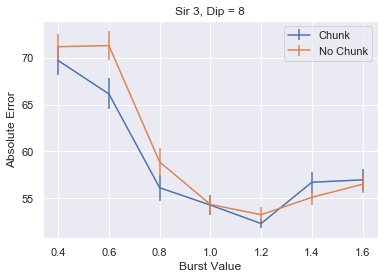

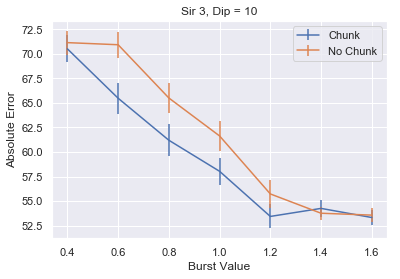

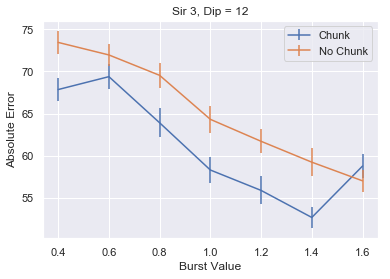

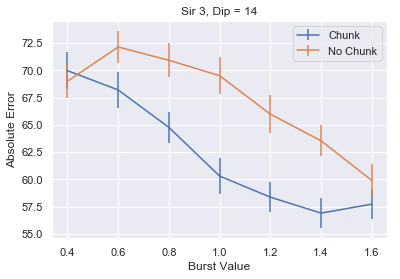

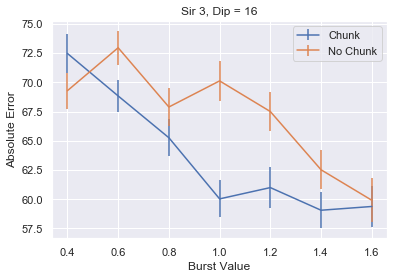

In [14]:

DipName = ["4"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["6"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["8"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["10"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["12"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


DipName = ["14"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


DipName = ["16"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 4, Dip = 16')

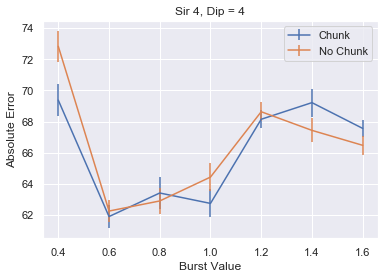

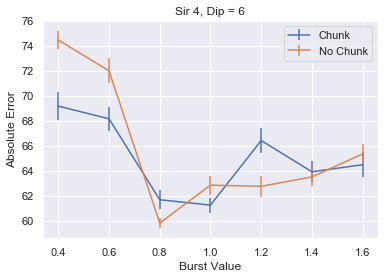

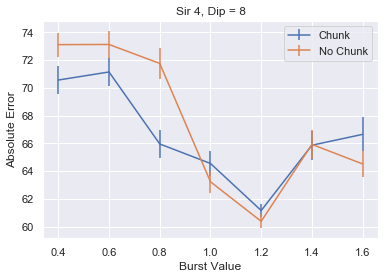

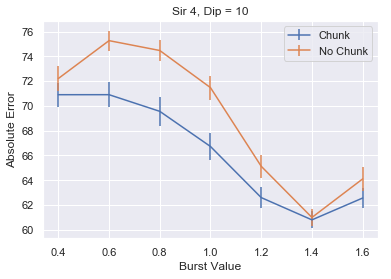

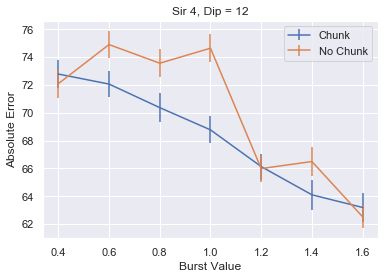

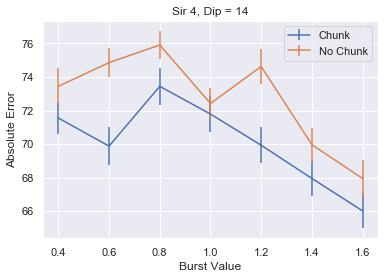

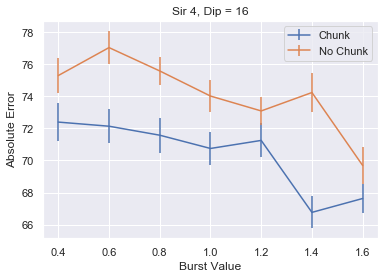

In [15]:

DipName = ["4"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["6"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["8"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["10"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

DipName = ["12"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


DipName = ["14"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


DipName = ["16"]
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = {}".format(DipName[0]))
# SSE_total = SSE_total+SSE
# SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80


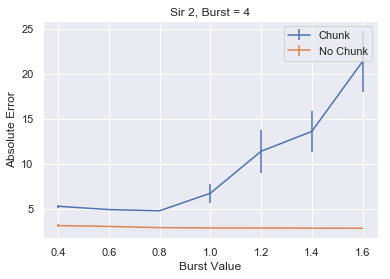

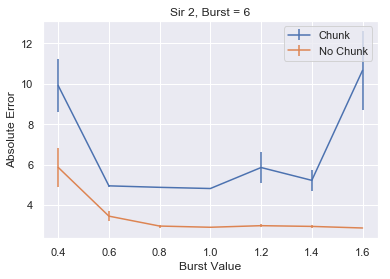

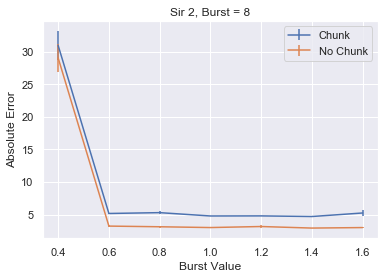

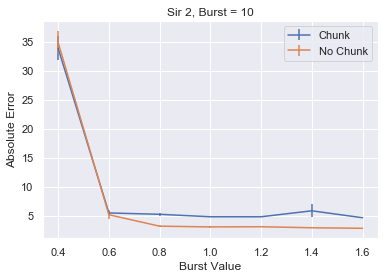

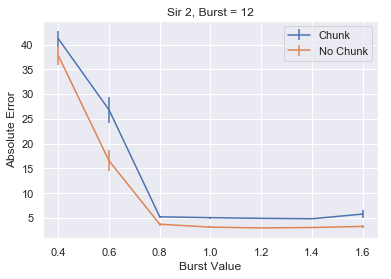

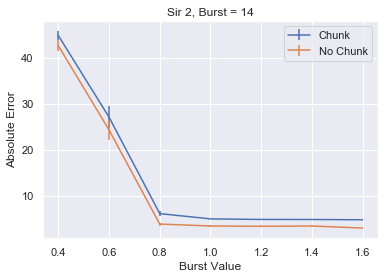

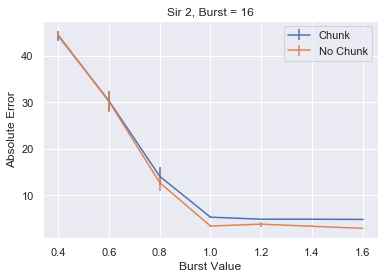

In [5]:
SSE_total= []
SSE_nochunk_total= []

BurstName = ["4"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["6"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["8"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["10"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["12"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["14"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80


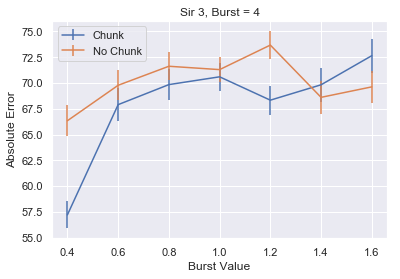

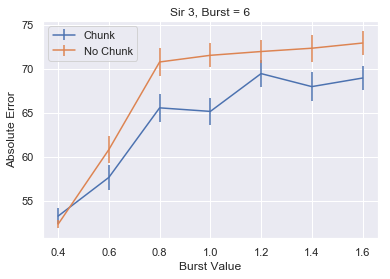

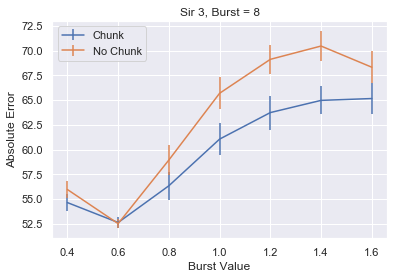

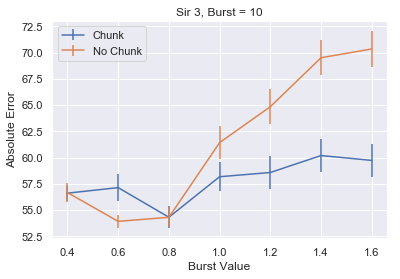

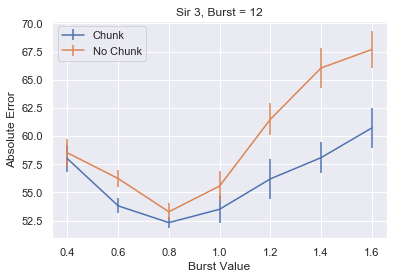

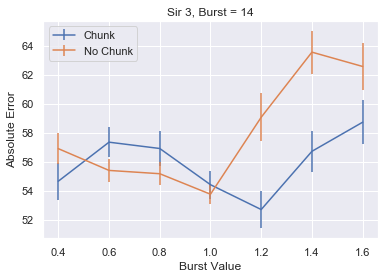

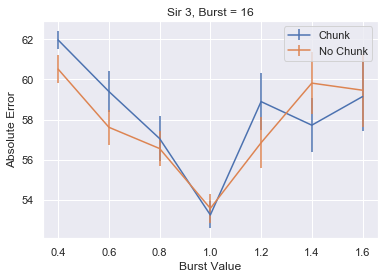

In [10]:
SSE_total= []
SSE_nochunk_total= []

BurstName = ["4"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["6"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["8"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["10"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["12"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["14"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


In [11]:
np.save("sir3_nohiddennostimloc_chunk_ABE", np.array(SSE_total))
np.save("sir3_nohiddennostimloc_nochunk_ABE", np.array(SSE_nochunk_total))

80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80


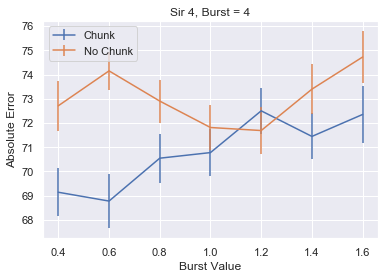

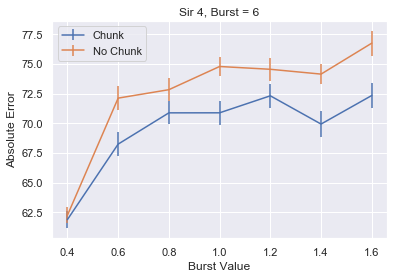

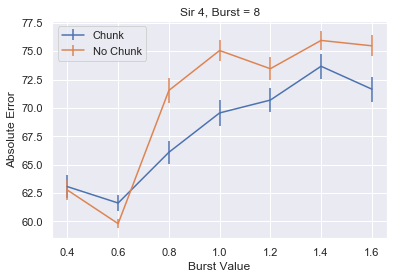

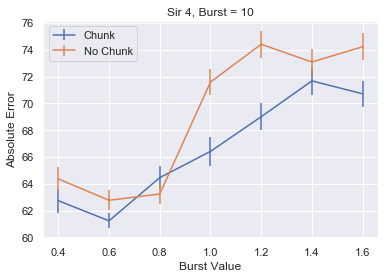

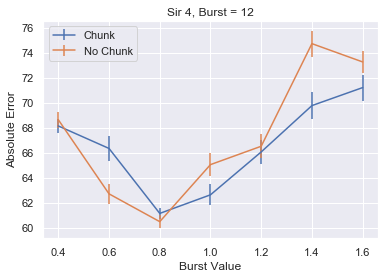

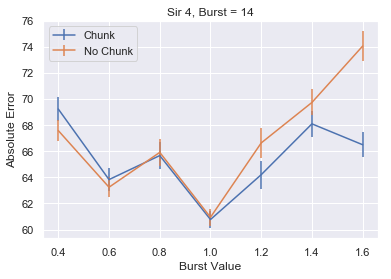

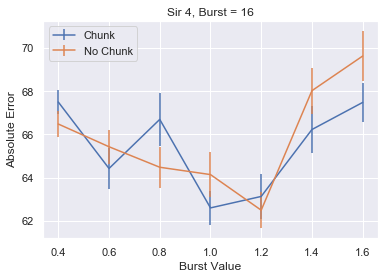

In [8]:
SSE_total= []
SSE_nochunk_total= []

BurstName = ["4"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["6"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["8"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["10"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["12"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["14"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


In [9]:
np.save("sir4_nohiddennostimloc_chunk_ABE", np.array(SSE_total))
np.save("sir4_nohiddennostimloc_nochunk_ABE", np.array(SSE_nochunk_total))

In [6]:
np.save("sir2_nohiddennostimloc_chunk_ABE", np.array(SSE_total))
np.save("sir2_nohiddennostimloc_nochunk_ABE", np.array(SSE_nochunk_total))

In [7]:
SSE_total= []
SSE_nochunk_total= []
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

In [13]:
np.save("sir4_nogo125_chunk_ABE", np.array(SSE_total))

In [16]:
np.save("sir4_nogo125_nochunk_ABE", np.array(SSE_nochunk_total))

80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80
80


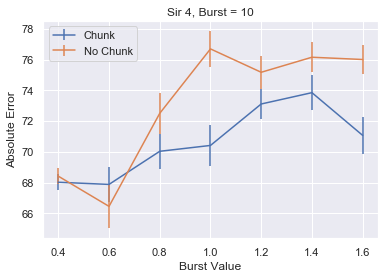

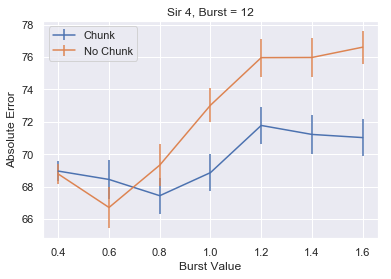

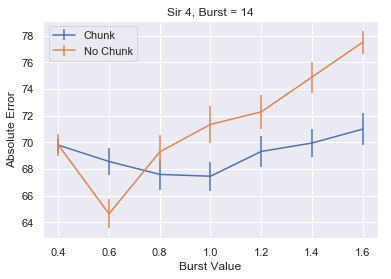

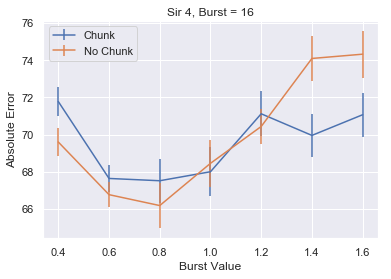

In [11]:
# SSE_total= []
# SSE_nochunk_total= []
BurstName = ["10"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk

BurstName = ["12"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["14"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


BurstName = ["16"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = {}".format(BurstName[0]))
SSE_total = SSE_total+SSE
SSE_nochunk_total = SSE_nochunk_total+SSE_nochunk


80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 4, Burst = 1.0')

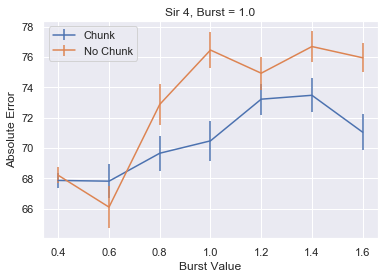

In [6]:
BurstName = ["10"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]

plt.figure()
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = 1.0")

80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 3, Burst = 1.0')

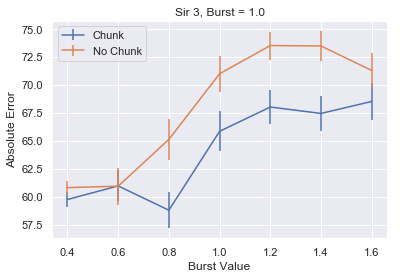

In [7]:
BurstName = ["10"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = 1.0")

80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 2, Burst = 1.0')

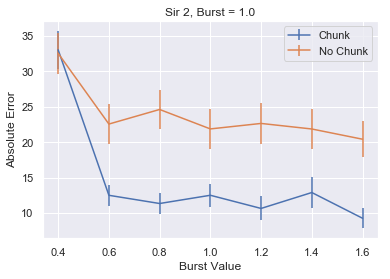

In [8]:
BurstName = ["10"]
DipName = ["4", "6", "8", "10", "12", "14", "16"]
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.figure()
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Burst = 1.0")

80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 4, Dip = 1.0')

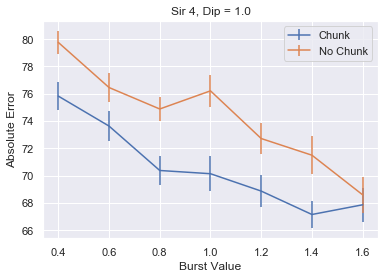

In [3]:
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
DipName = ["10"]
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')

base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName, add_folder = 'TestNoGo125/')

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = 1.0")


80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 3, Dip = 1.0')

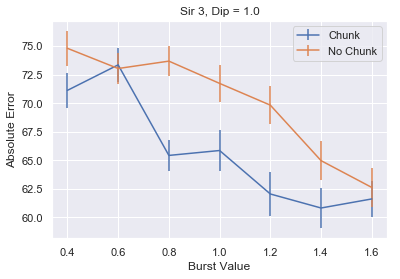

In [13]:
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
DipName = ["10"]
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName,add_folder = 'TestNoGo125/')

base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName,add_folder = 'TestNoGo125/')

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = 1.0")


80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 2, Dip = 1.0')

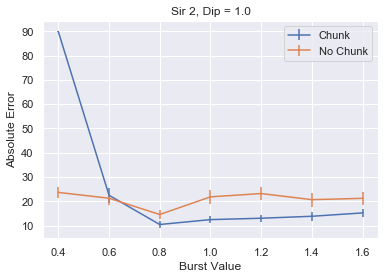

In [18]:
BurstName = ["4", "6", "8", "10", "12", "14", "16"]
DipName = ["10"]
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName,add_folder = 'TestNoGo125/')

base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName,add_folder = 'TestNoGo125/')

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = 1.0")


80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 2, Dip = 1.0')

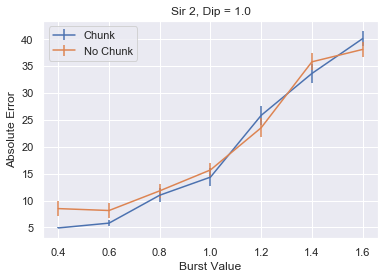

In [4]:
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)

base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = 1.0")


80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 3, Dip = 1.0')

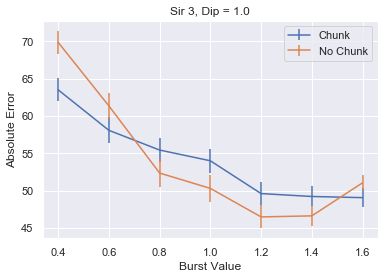

In [5]:
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)

base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = 1.0")


80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 4, Dip = 1.0')

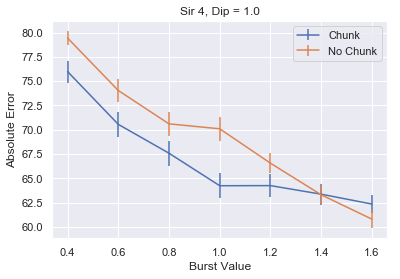

In [6]:
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)

base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),SSE, yerr = SSE_std)
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = 1.0")


80
80
80
80
80
80
80
80
80
80
80
80
80
80


Text(0.5, 1.0, 'Sir 4, Dip = 1.0')

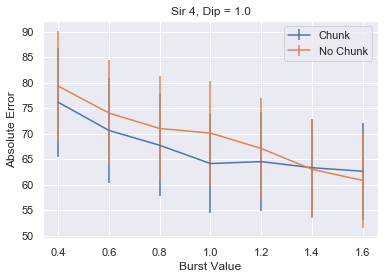

In [22]:
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
SSE, SSE_std = burstdip_mse(base,BurstName, DipName)

base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
SSE_nochunk, SSE_std_nochunk = burstdip_mse(base,BurstName, DipName)

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),SSE, yerr = SSE_std/np.sqrt(80))
plt.errorbar(range(7),SSE_nochunk, yerr = SSE_std_nochunk/np.sqrt(80))
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = 1.0")


Text(0.5, 1.0, 'Sir 4, Dip = 1.0')

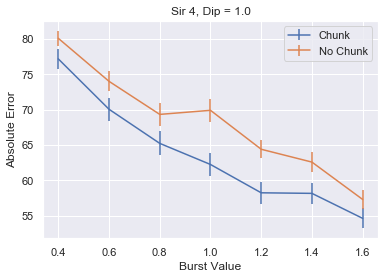

In [13]:
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE, last_epoch_std = burstdip_lastepoch(base,BurstName, DipName)

base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunk, last_epoch_std_nochunk = burstdip_lastepoch(base,BurstName, DipName)

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),last_epoch_SSE, yerr = last_epoch_std/np.sqrt(80))
plt.errorbar(range(7),last_epoch_SSE_nochunk, yerr = last_epoch_std_nochunk/np.sqrt(80))
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = 1.0")


Text(0.5, 1.0, 'Sir 3, Dip = 1.0')

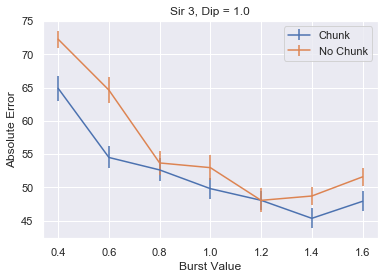

In [14]:
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE, last_epoch_std = burstdip_lastepoch(base,BurstName, DipName)

base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunk, last_epoch_std_nochunk = burstdip_lastepoch(base,BurstName, DipName)

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),last_epoch_SSE, yerr = last_epoch_std/np.sqrt(80))
plt.errorbar(range(7),last_epoch_SSE_nochunk, yerr = last_epoch_std_nochunk/np.sqrt(80))
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = 1.0")


Text(0.5, 1.0, 'Sir 2, Dip = 1.0')

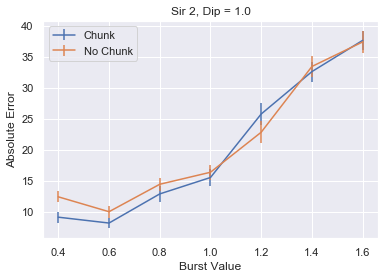

In [15]:
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE, last_epoch_std = burstdip_lastepoch(base,BurstName, DipName)

base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunk, last_epoch_std_nochunk = burstdip_lastepoch(base,BurstName, DipName)

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.errorbar(range(7),last_epoch_SSE, yerr = last_epoch_std/np.sqrt(80))
plt.errorbar(range(7),last_epoch_SSE_nochunk, yerr = last_epoch_std_nochunk/np.sqrt(80))
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = 1.0")


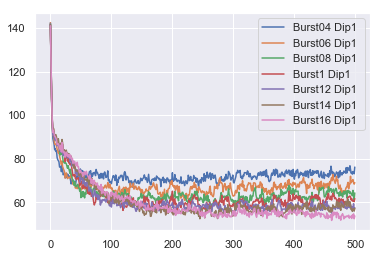

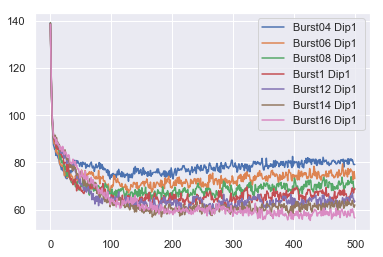

Text(0.5, 1.0, 'Sir 4, Dip = 1.0')

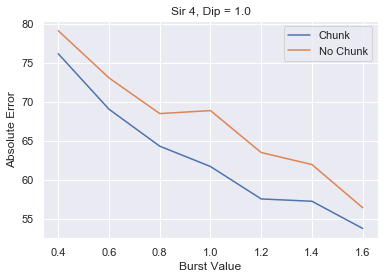

In [8]:
BurstName =["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSEDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunkDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)

dipname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.plot(last_epoch_SSEDip)
plt.plot(last_epoch_SSE_nochunkDip)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = dipname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = 1.0")

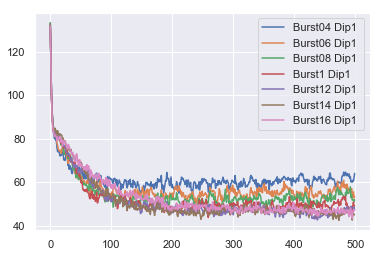

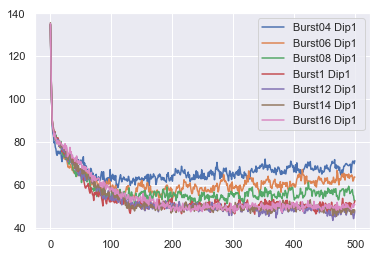

Text(0.5, 1.0, 'Sir 3, Dip = 1.0')

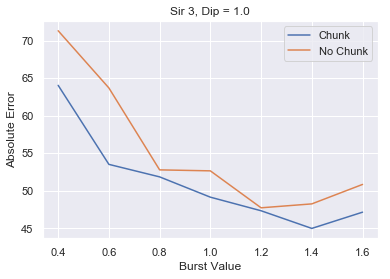

In [7]:
BurstName =["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSEDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunkDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)

dipname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.plot(last_epoch_SSEDip)
plt.plot(last_epoch_SSE_nochunkDip)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = dipname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Dip = 1.0")

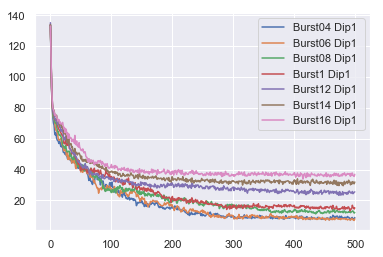

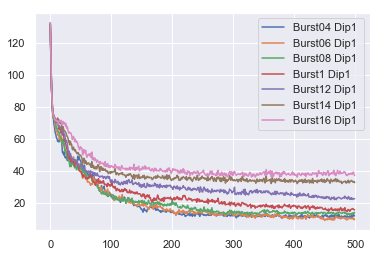

Text(0.5, 1.0, 'Sir 2, Dip = 1.0')

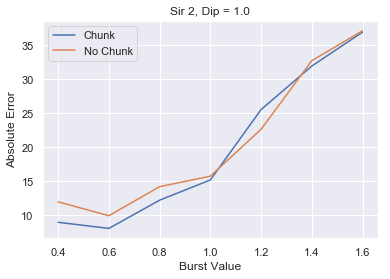

In [6]:
BurstName =["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSEDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunkDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)

dipname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.plot(last_epoch_SSEDip)
plt.plot(last_epoch_SSE_nochunkDip)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = dipname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Dip = 1.0")

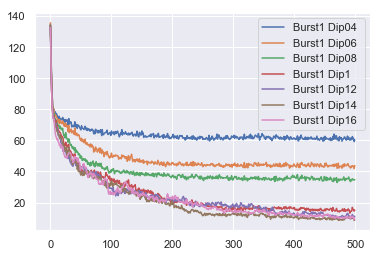

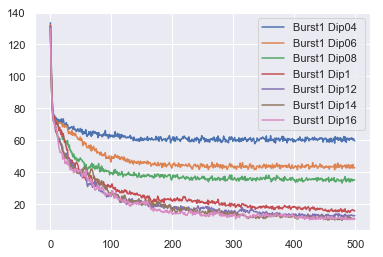

Text(0.5, 1.0, 'Sir 2, Burst = 1.0')

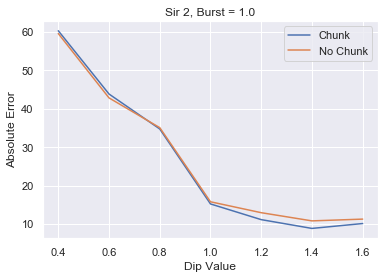

In [5]:
BurstName =["1"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSEDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)
BurstName = ["1"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunkDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.plot(last_epoch_SSEDip)
plt.plot(last_epoch_SSE_nochunkDip)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Dip Value')
plt.ylabel("Absolute Error")
plt.title("Sir 2, Burst = 1.0")

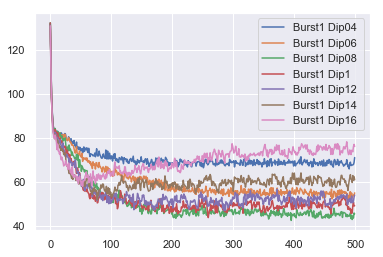

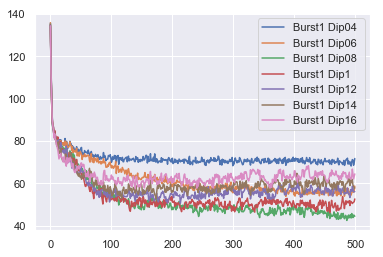

Text(0.5, 1.0, 'Sir 3, Burst = 1.0')

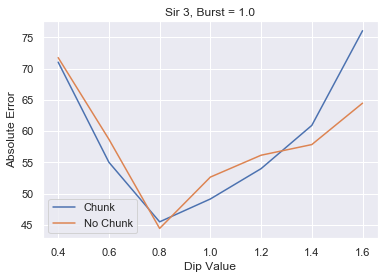

In [4]:
BurstName =["1"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSEDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)
BurstName = ["1"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunkDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)

burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.plot(last_epoch_SSEDip)
plt.plot(last_epoch_SSE_nochunkDip)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Dip Value')
plt.ylabel("Absolute Error")
plt.title("Sir 3, Burst = 1.0")

Text(0.5, 1.0, 'Sir 4, Burst = 1.0')

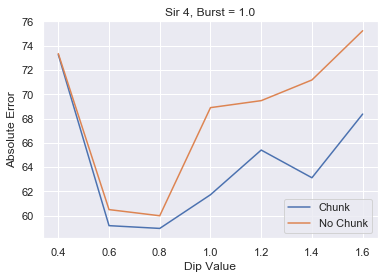

In [27]:
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.plot(last_epoch_SSEDip)
plt.plot(last_epoch_SSE_nochunkDip)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Dip Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Burst = 1.0")

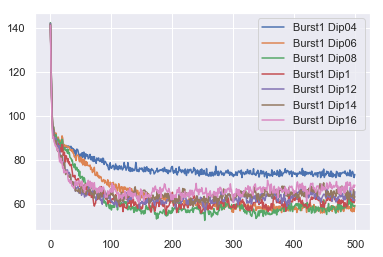

In [25]:
BurstName =["1"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSEDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)

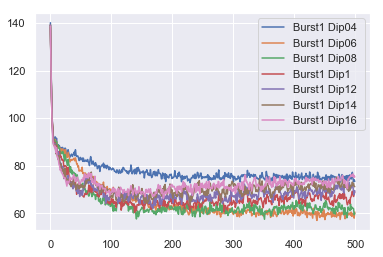

In [26]:
BurstName = ["1"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunkDip = burstdip_indlc(base,BurstName, DipName, last_epoch = True)

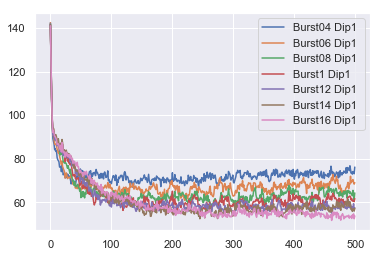

In [17]:
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE = burstdip_indlc(base,BurstName, DipName, last_epoch = True
                               )

Text(0.5, 1.0, 'Sir 4, Dip = 1.0')

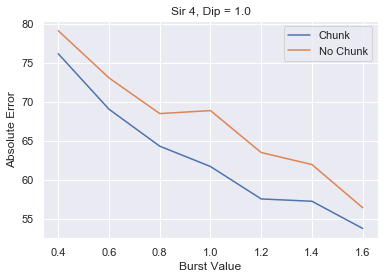

In [24]:
burstname = ["0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6"]
plt.plot(last_epoch_SSE)
plt.plot(last_epoch_SSE_nochunk)
plt.legend(['Chunk', 'No Chunk'])
plt.xticks(range(7), labels = burstname)
plt.xlabel('Burst Value')
plt.ylabel("Absolute Error")
plt.title("Sir 4, Dip = 1.0")

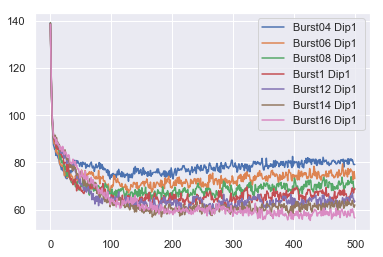

In [23]:
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["1"]
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
last_epoch_SSE_nochunk = burstdip_indlc(base,BurstName, DipName, last_epoch = True)

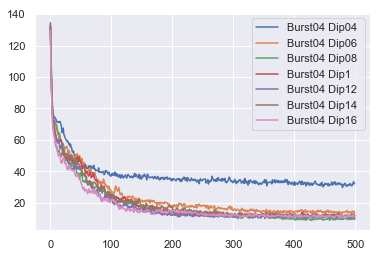

In [8]:
BurstName = ["04"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
burstdip_indlc(base,BurstName, DipName)

In [14]:
BurstName

'04'

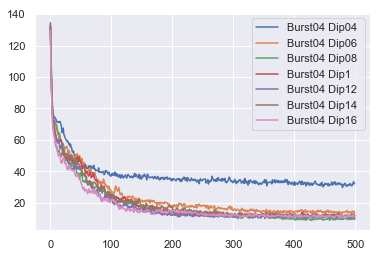

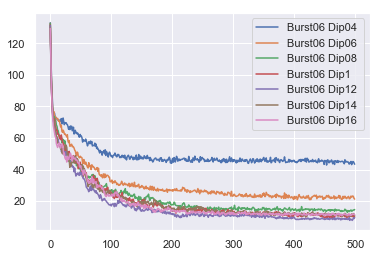

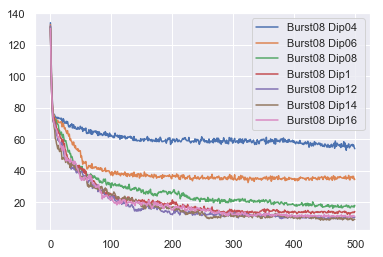

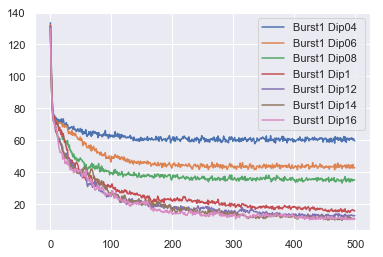

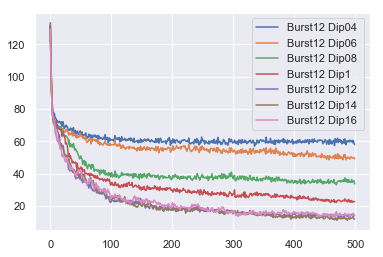

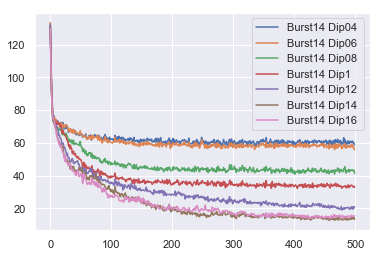

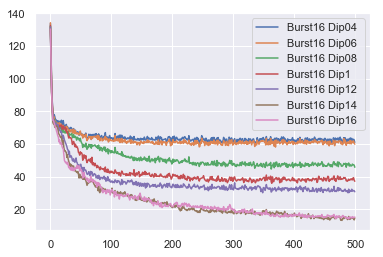

In [18]:
Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstNameAll = ["04", "06", "08", "1", "12", "14", "16"]
for b in range(len(Burst)):
    BurstName = [BurstNameAll[b]]
    DipName = ["04", "06", "08", "1", "12", "14", "16"]
    base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
    plt.figure()
    burstdip_indlc(base,BurstName, DipName)

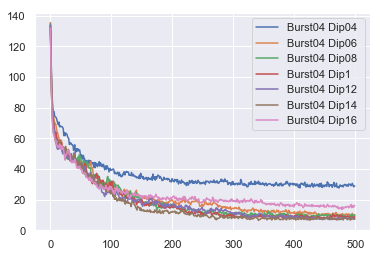

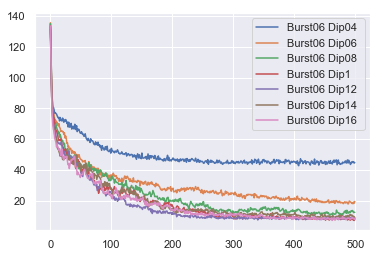

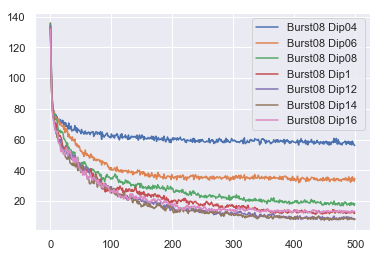

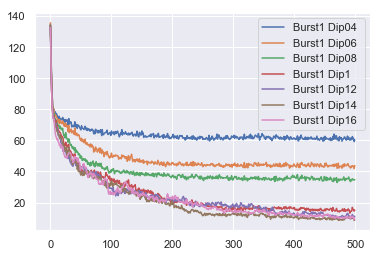

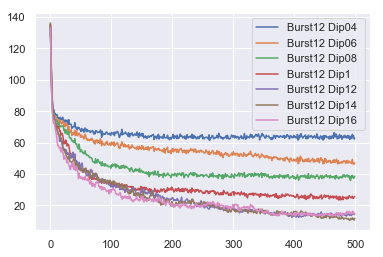

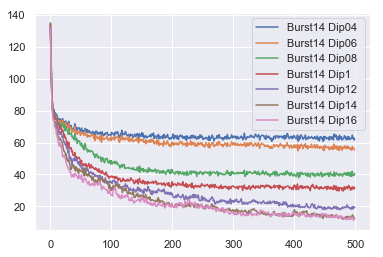

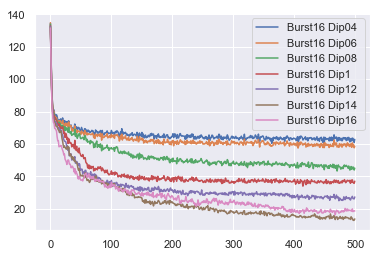

In [19]:
Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstNameAll = ["04", "06", "08", "1", "12", "14", "16"]
for b in range(len(Burst)):
    BurstName = [BurstNameAll[b]]
    DipName = ["04", "06", "08", "1", "12", "14", "16"]
    base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
    plt.figure()
    burstdip_indlc(base,BurstName, DipName)

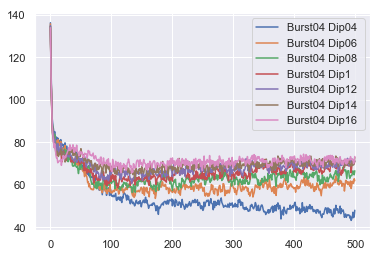

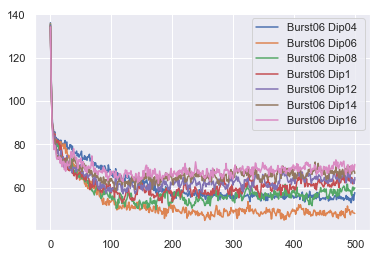

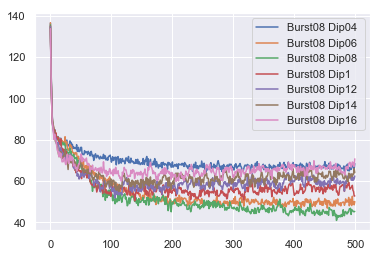

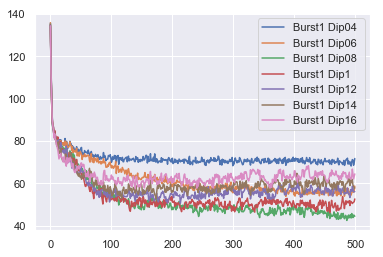

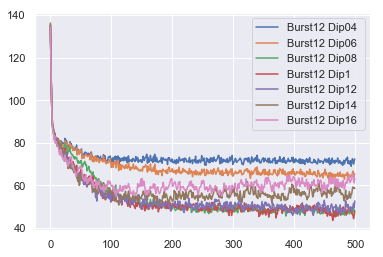

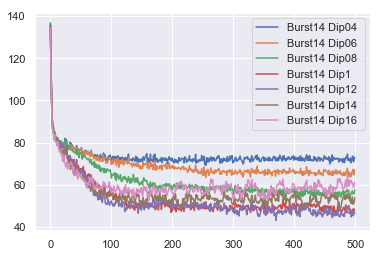

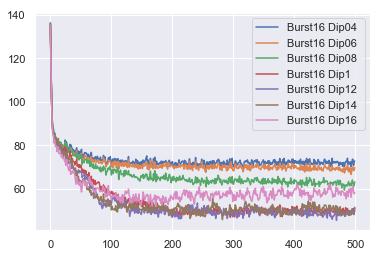

In [20]:
Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstNameAll = ["04", "06", "08", "1", "12", "14", "16"]
for b in range(len(Burst)):
    BurstName = [BurstNameAll[b]]
    DipName = ["04", "06", "08", "1", "12", "14", "16"]
    base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
    plt.figure()
    burstdip_indlc(base,BurstName, DipName)

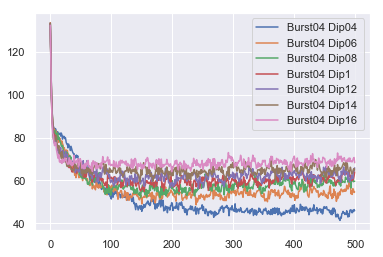

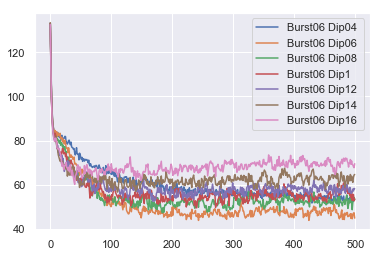

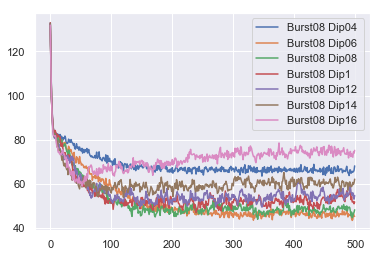

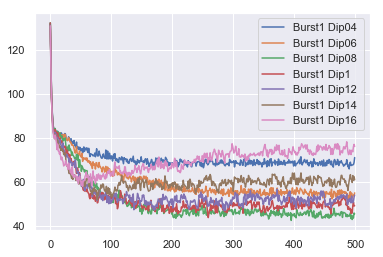

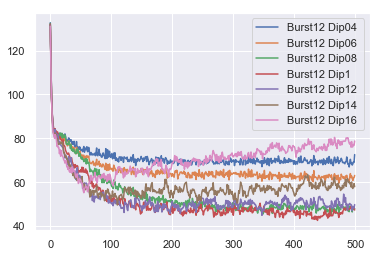

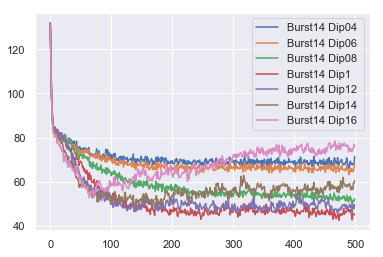

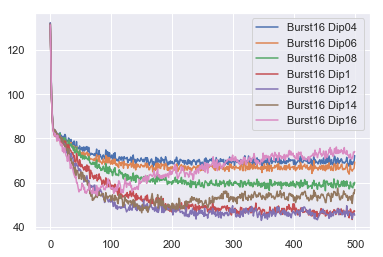

In [21]:
Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstNameAll = ["04", "06", "08", "1", "12", "14", "16"]
for b in range(len(Burst)):
    BurstName = [BurstNameAll[b]]
    DipName = ["04", "06", "08", "1", "12", "14", "16"]
    base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
    plt.figure()
    burstdip_indlc(base,BurstName, DipName)

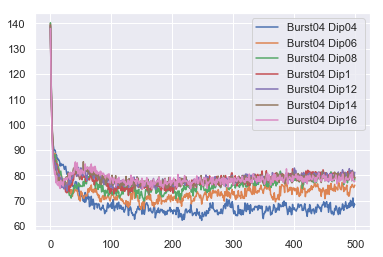

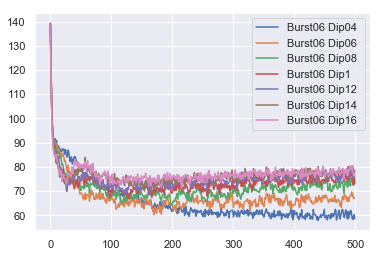

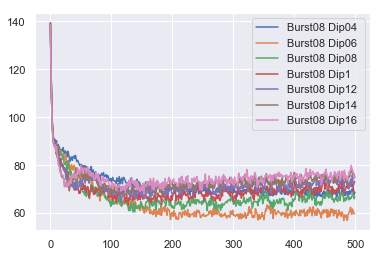

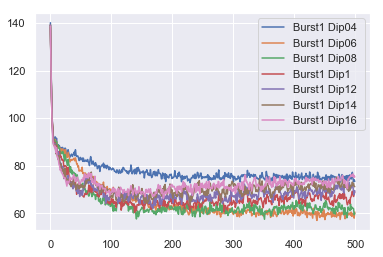

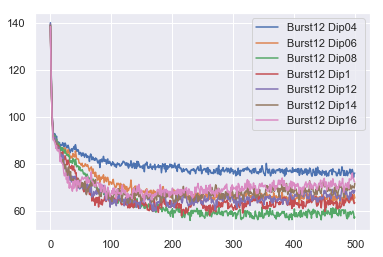

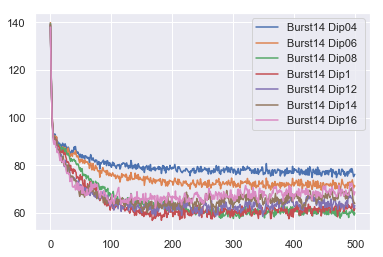

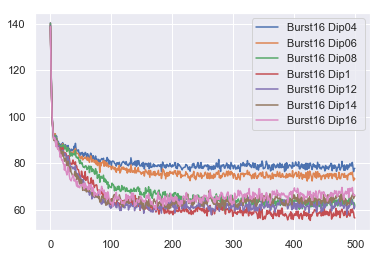

In [22]:
Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstNameAll = ["04", "06", "08", "1", "12", "14", "16"]
for b in range(len(Burst)):
    BurstName = [BurstNameAll[b]]
    DipName = ["04", "06", "08", "1", "12", "14", "16"]
    base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
    plt.figure()
    burstdip_indlc(base,BurstName, DipName)

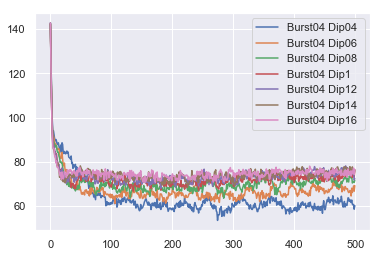

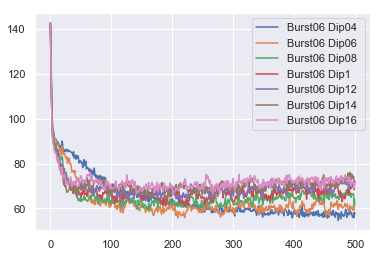

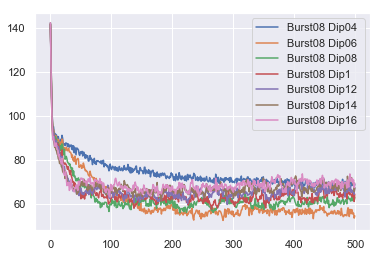

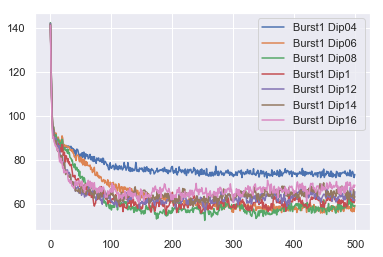

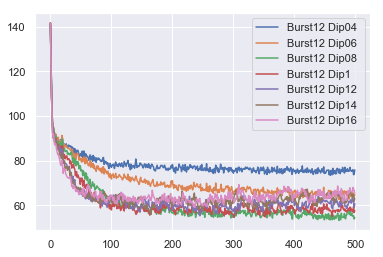

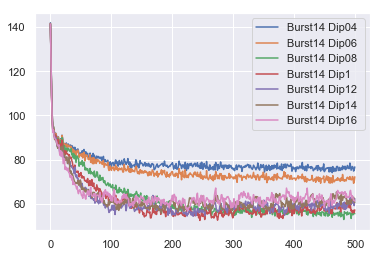

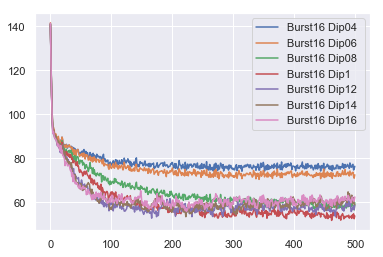

In [23]:
Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstNameAll = ["04", "06", "08", "1", "12", "14", "16"]
for b in range(len(Burst)):
    BurstName = [BurstNameAll[b]]
    DipName = ["04", "06", "08", "1", "12", "14", "16"]
    base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
    plt.figure()
    burstdip_indlc(base,BurstName, DipName)

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip04/


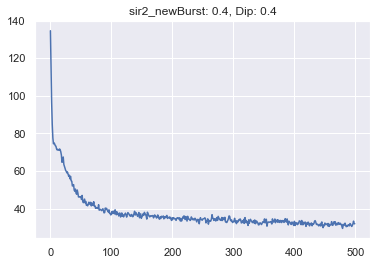

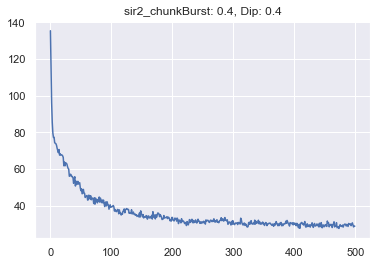

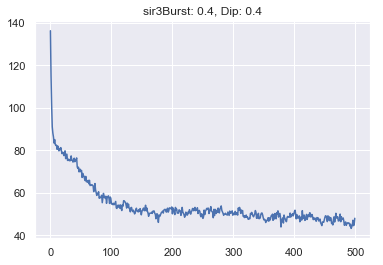

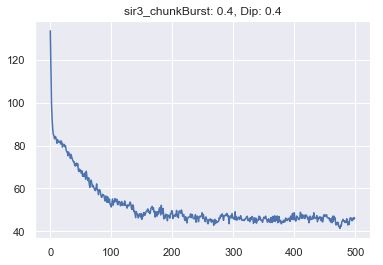

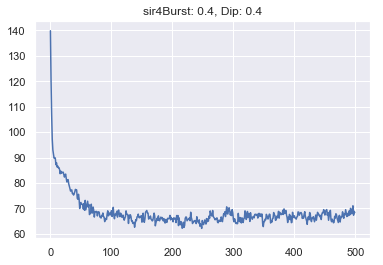

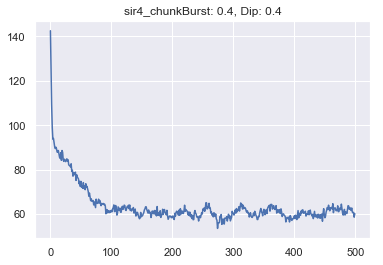

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip06/


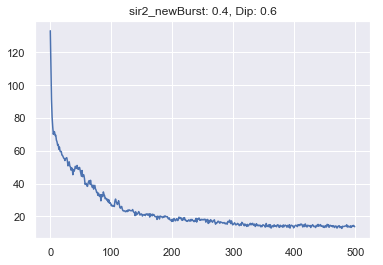

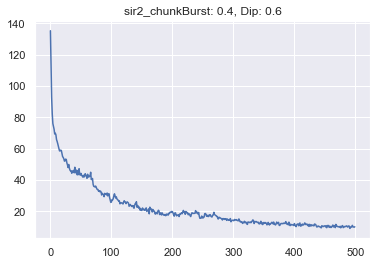

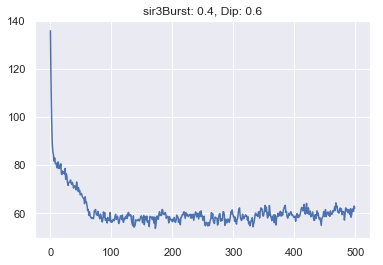

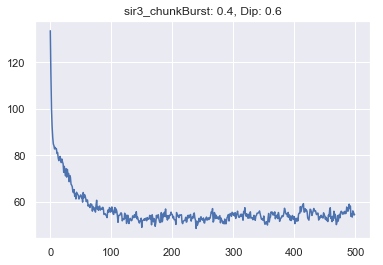

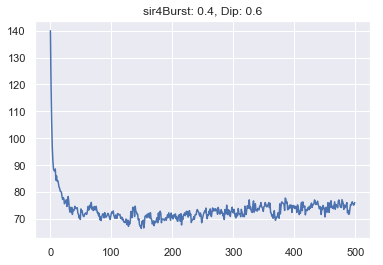

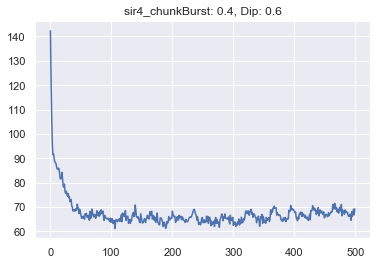

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip08/


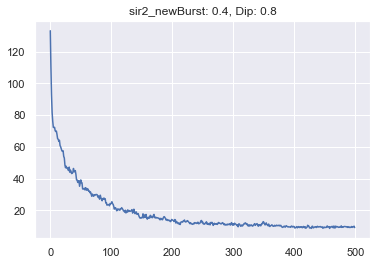

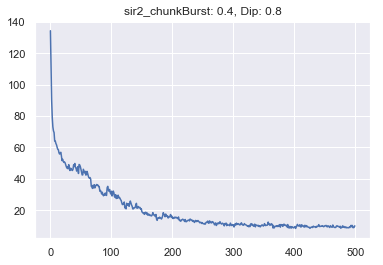

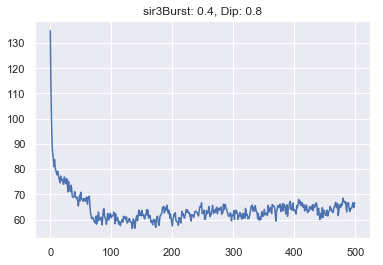

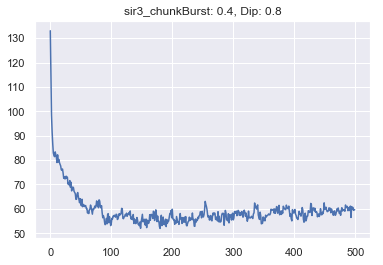

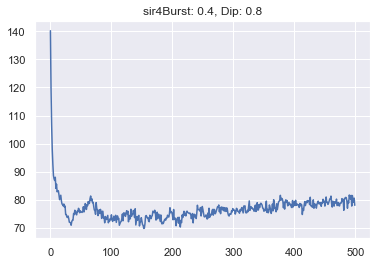

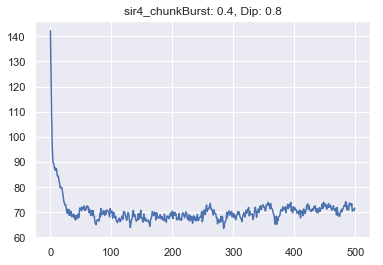

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip1/


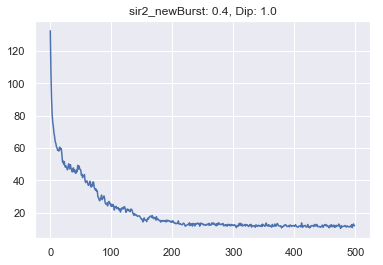

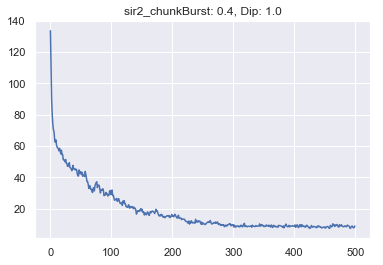

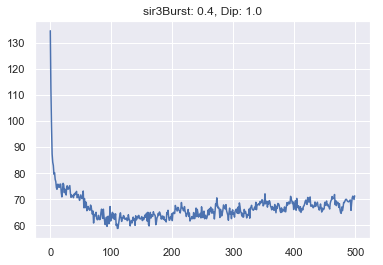

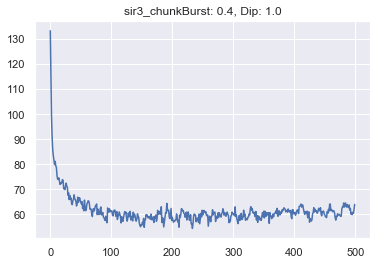

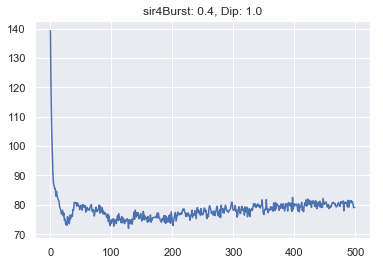

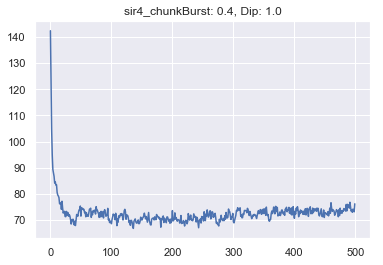

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip12/


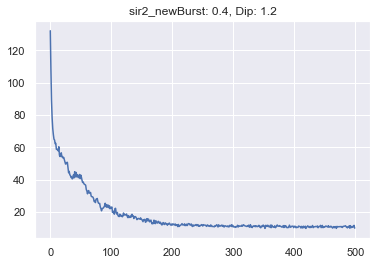

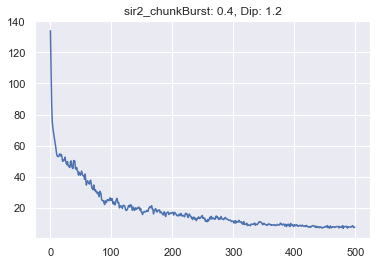

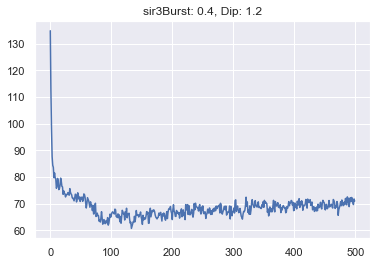

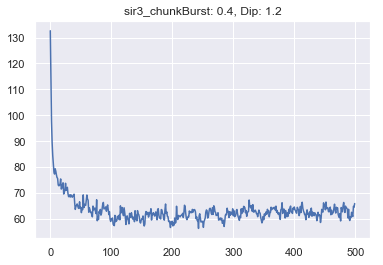

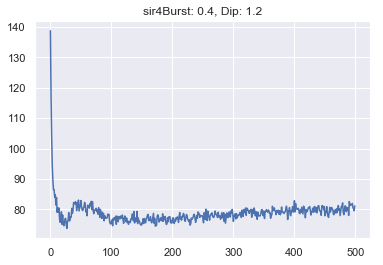

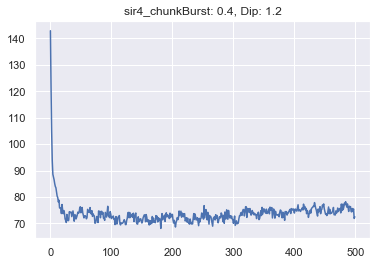

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip14/


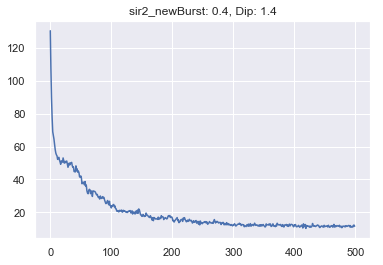

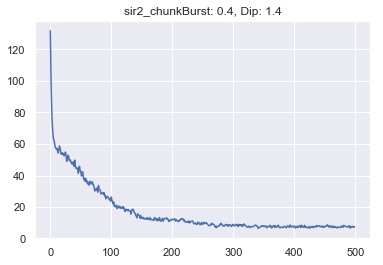

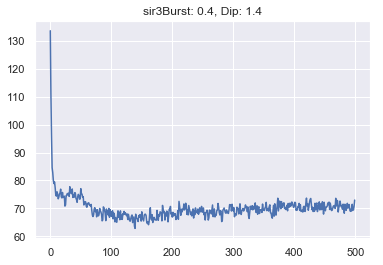

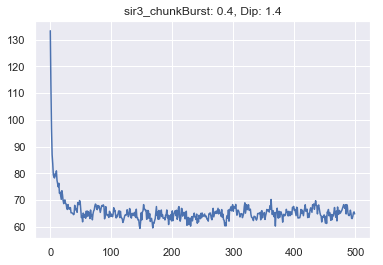

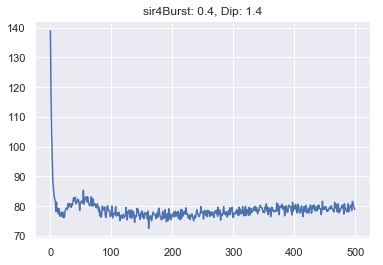

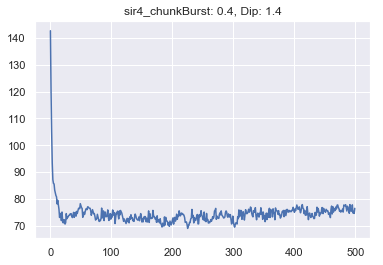

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip16/


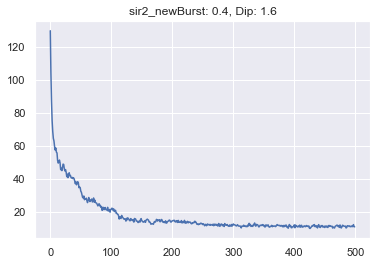

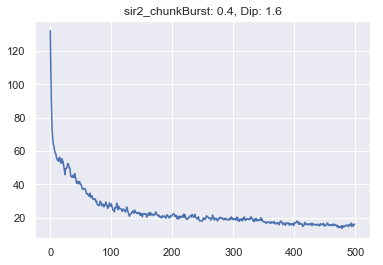

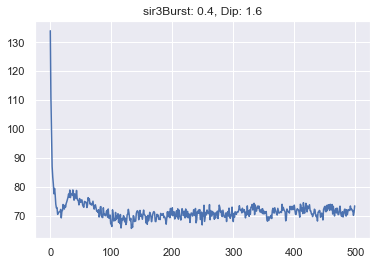

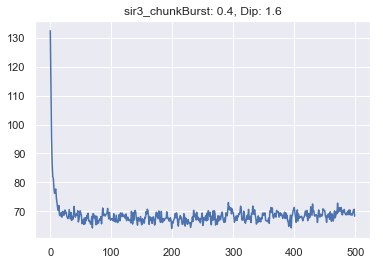

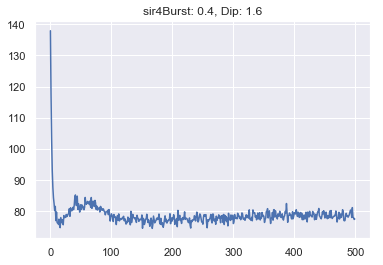

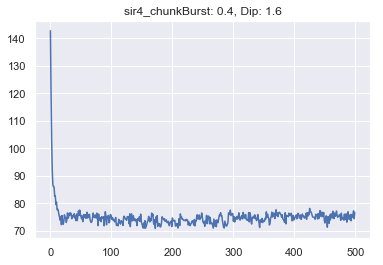

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip04/


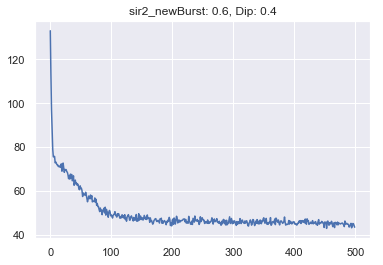

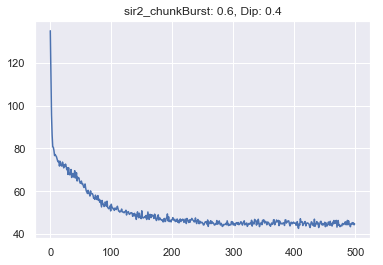

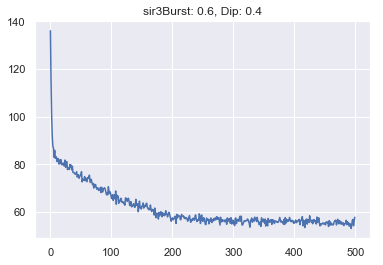

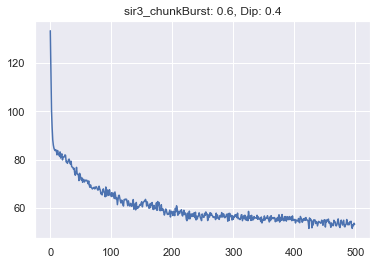

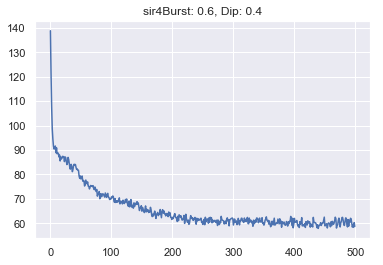

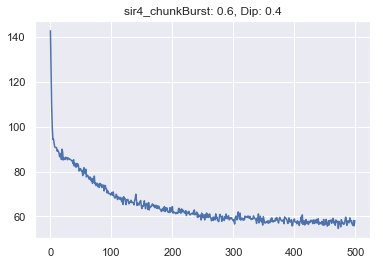

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip06/


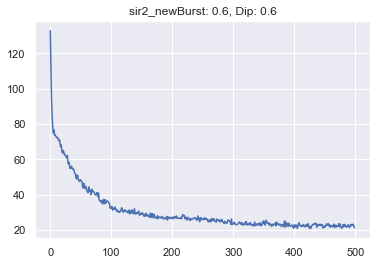

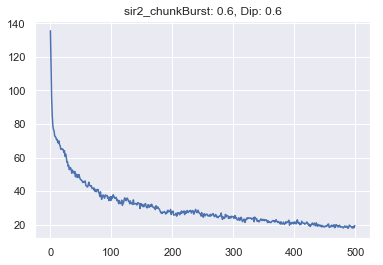

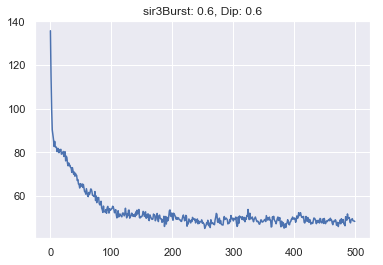

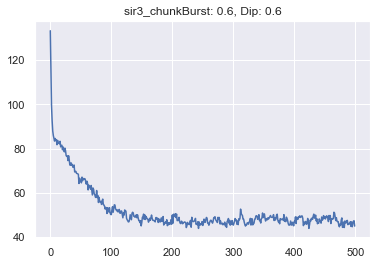

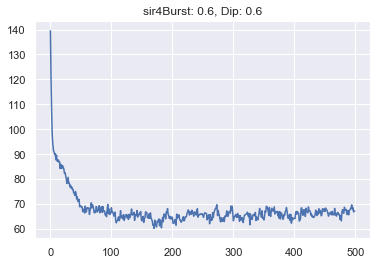

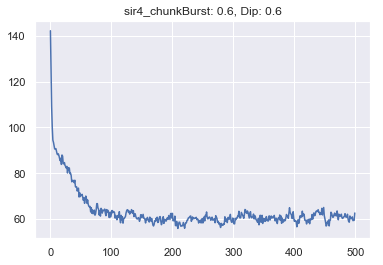

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip08/


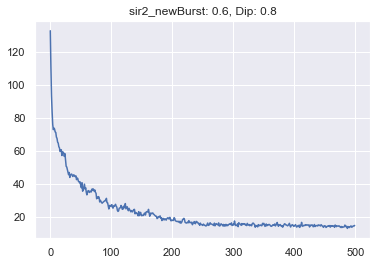

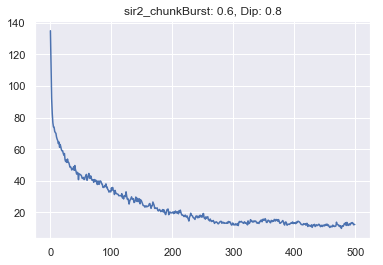

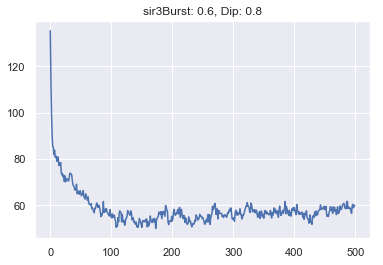

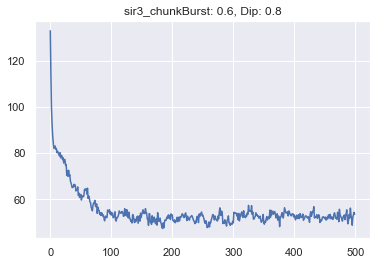

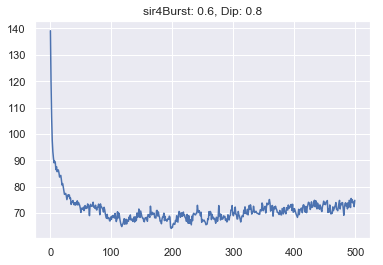

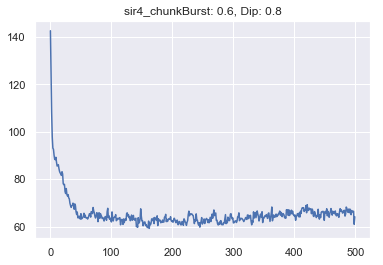

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip1/


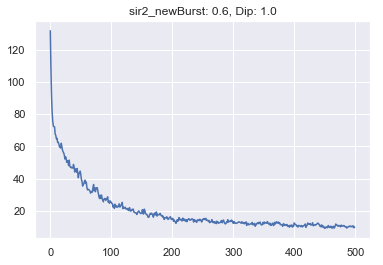

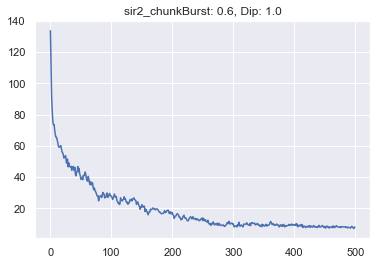

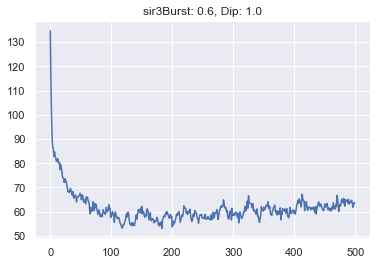

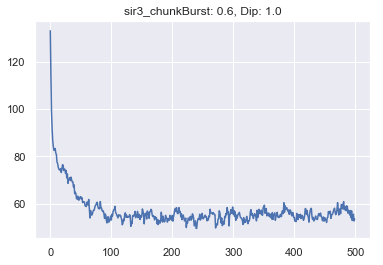

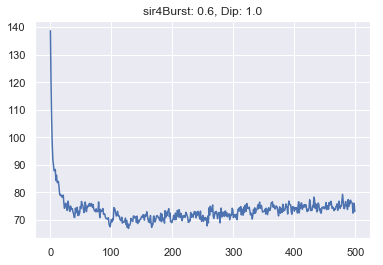

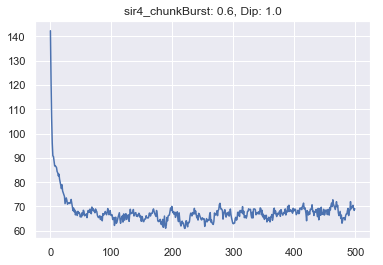

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip12/


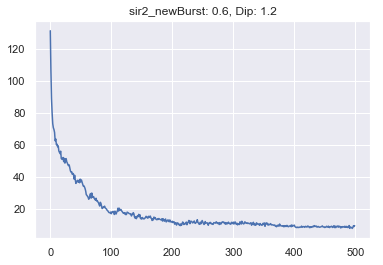

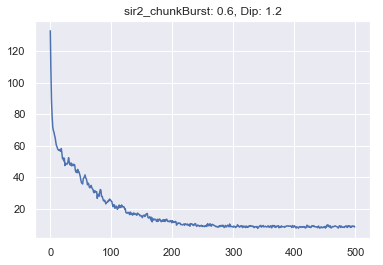

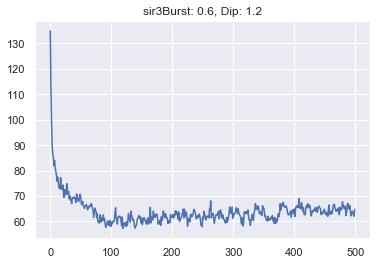

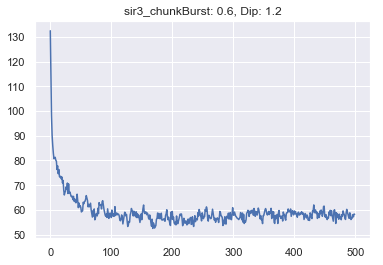

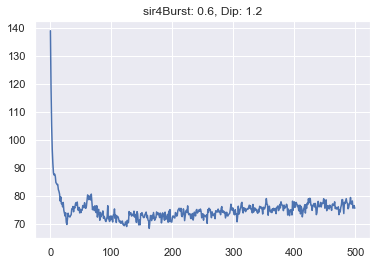

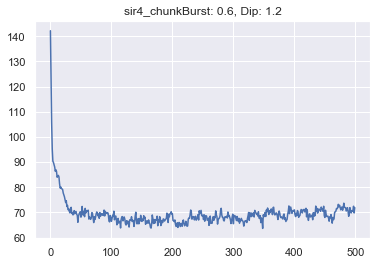

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip14/


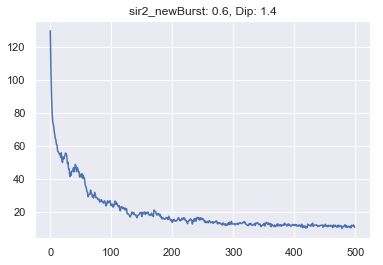

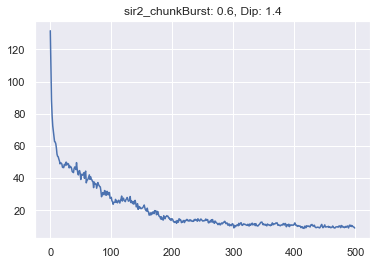

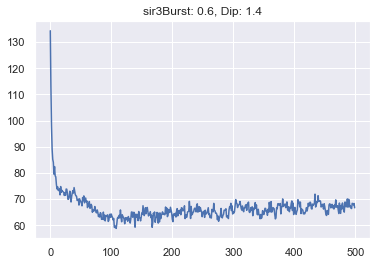

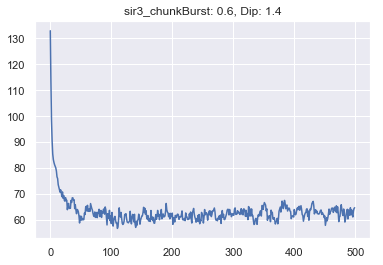

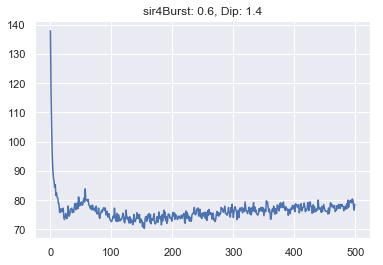

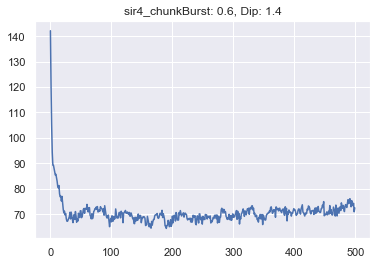

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip16/


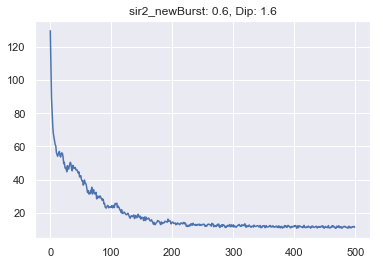

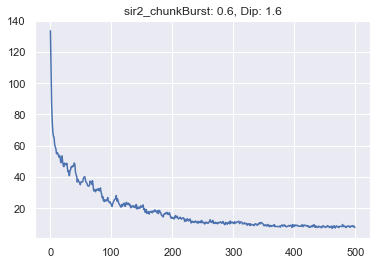

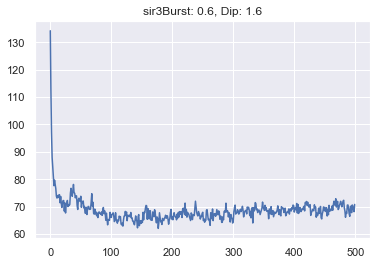

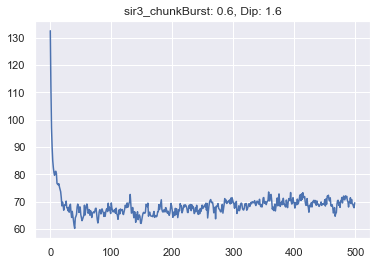

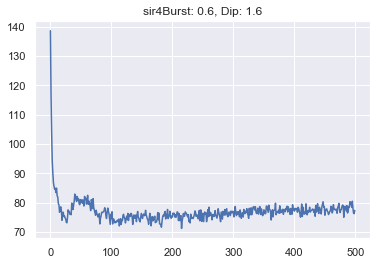

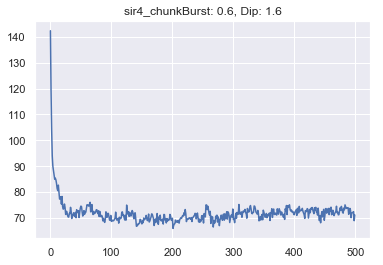

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip04/


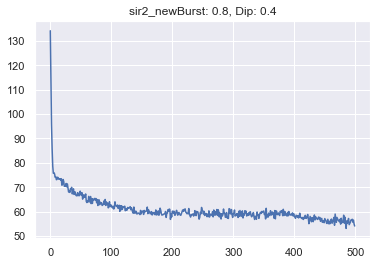

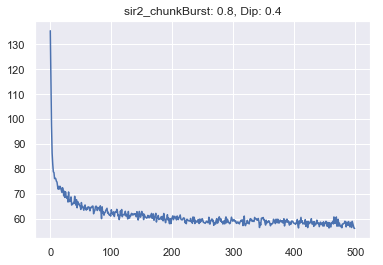

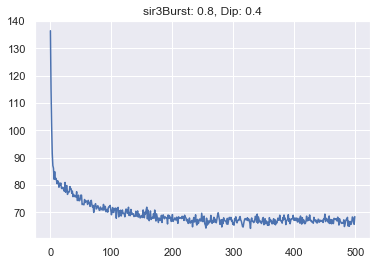

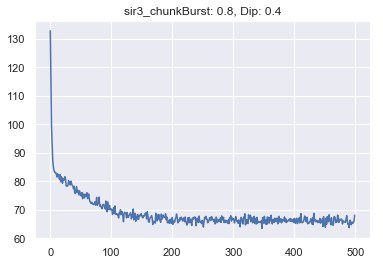

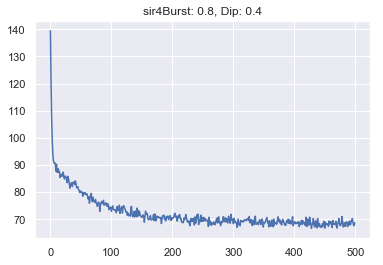

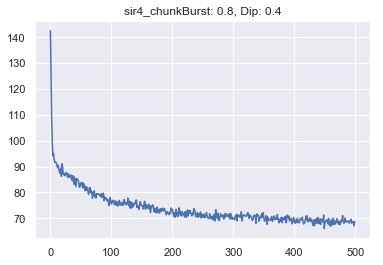

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip06/


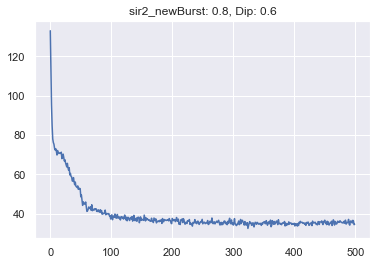

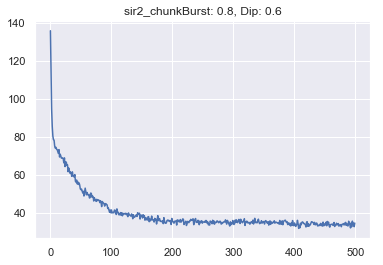

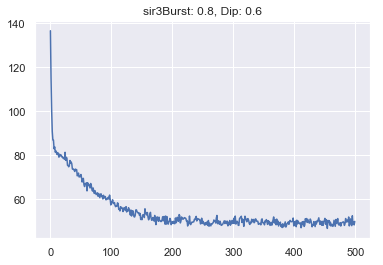

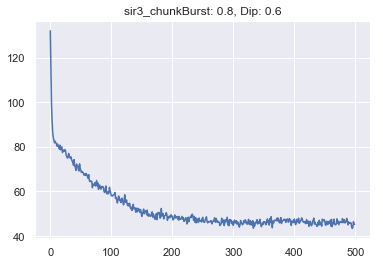

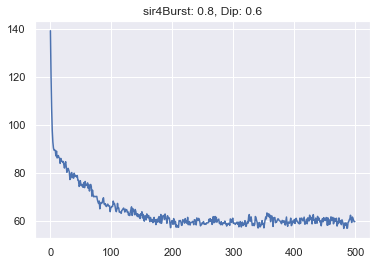

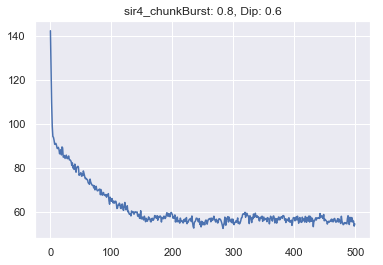

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip08/


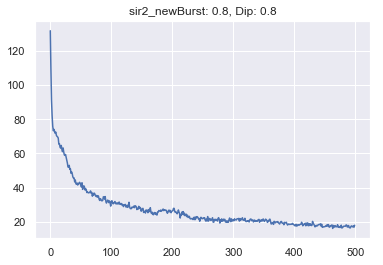

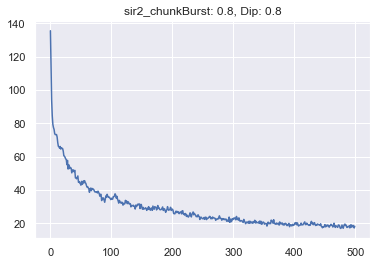

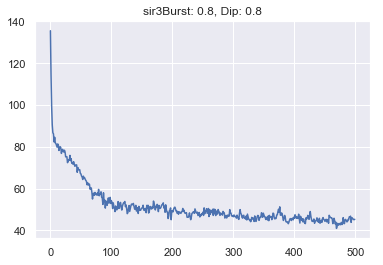

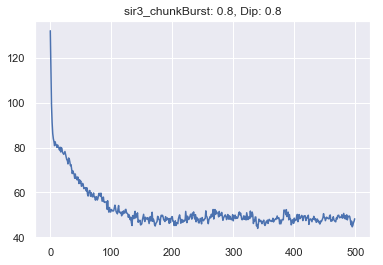

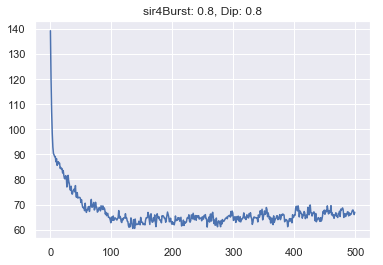

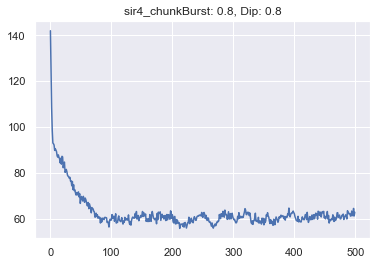

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip1/


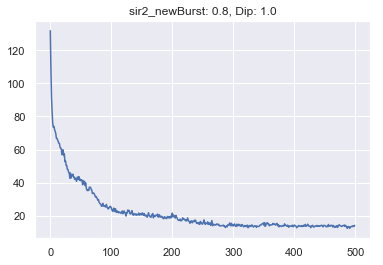

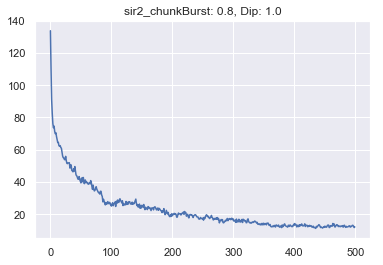

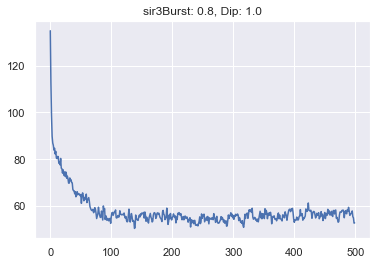

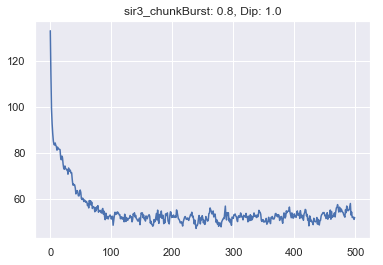

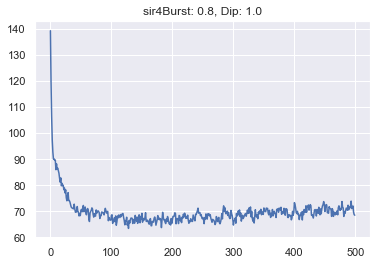

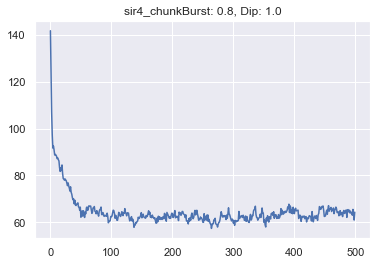

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip12/


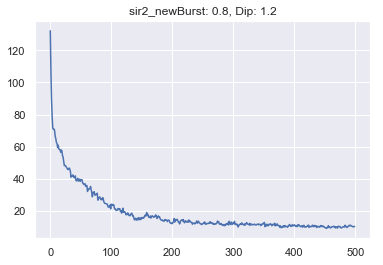

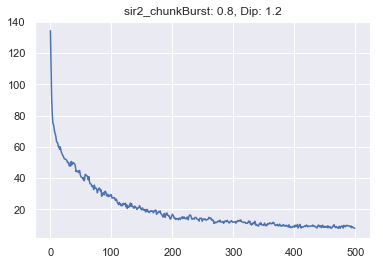

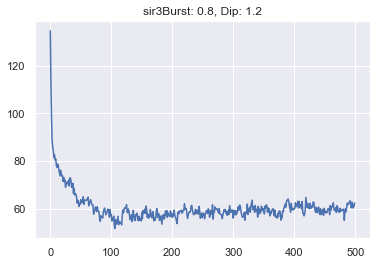

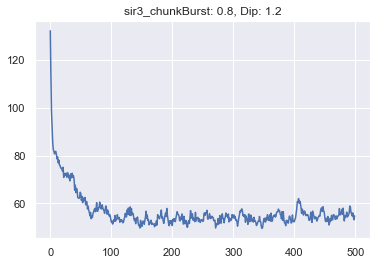

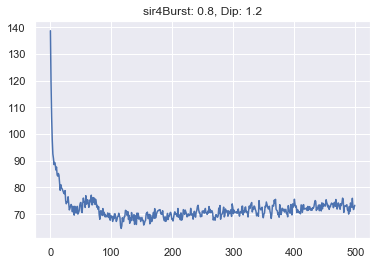

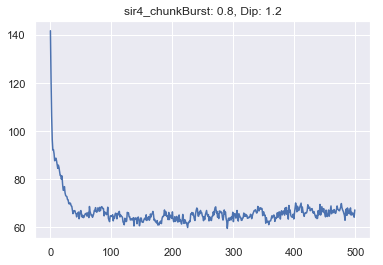

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip14/


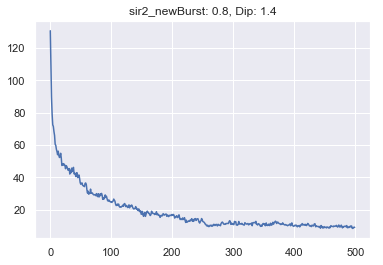

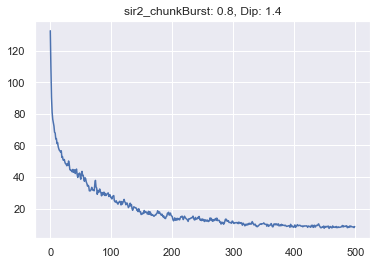

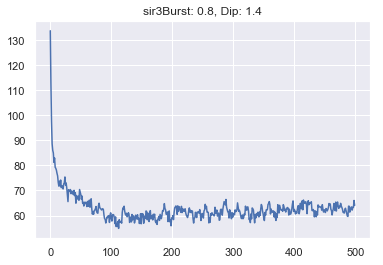

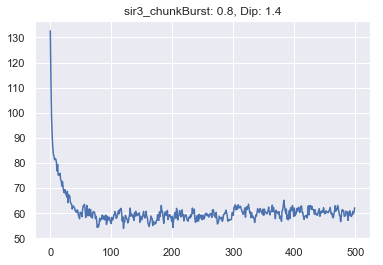

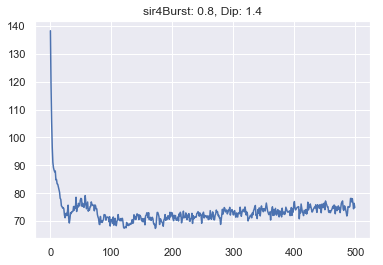

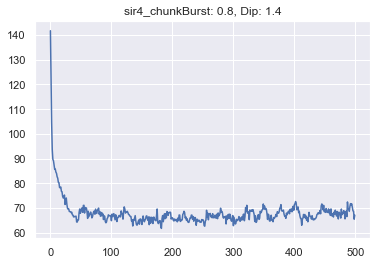

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip16/


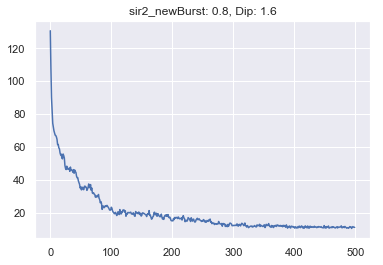

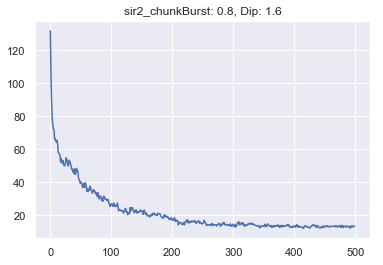

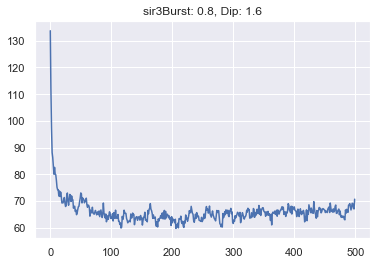

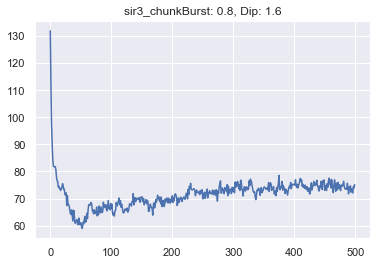

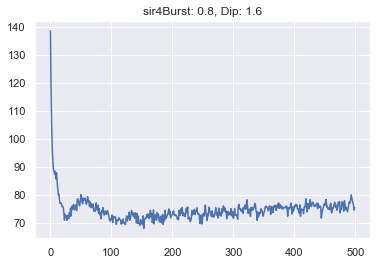

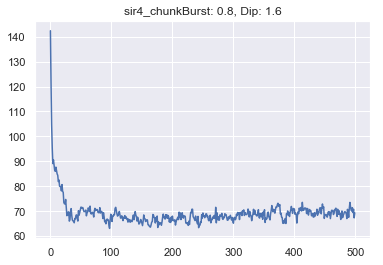

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst1/Dip04/


KeyboardInterrupt: 

<Figure size 432x288 with 0 Axes>

In [11]:
Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName = ["04", "06", "08", "1", "12", "14", "16"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]
base = "Y:/"
base2 = "results/Ring/2Stripe/"
for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain
        print(experiment)
        burstdipLC(base,base2,experiment, Burst[burst], Dip[dip])


In [ ]:
Burst = [0.5,1.5]
Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
BurstName = ["05", "15"]
DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain
        print(experiment)
        burstdip_allmodels(base,base2,experiment, Burst[burst], Dip[dip])
        plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+".png")
        

In [39]:
Burst = [0.8,0.9,1.0,1.1,1.2]
Dip = [0.8,0.9,1.0,1.1,1.2]
BurstName = ["08", "09", "1", "11", "12"]
DipName = ["08", "09", "1", "11", "12"]

In [45]:
Burst = [1.2]
Dip = [0.8,0.9,1.0,1.1,1.2]
BurstName = ["12"]
DipName = ["08", "09", "1", "11", "12"]

decodedrew/contNoStimLoc/NoIgnore/sigma12/Burst12/Dip08/
80
80
80
80
80
80
decodedrew/contNoStimLoc/NoIgnore/sigma12/Burst12/Dip09/
80
80
80
80
80
80
decodedrew/contNoStimLoc/NoIgnore/sigma12/Burst12/Dip1/
80
80
80
80
80
80
decodedrew/contNoStimLoc/NoIgnore/sigma12/Burst12/Dip11/
80
80
80
80
80
80
decodedrew/contNoStimLoc/NoIgnore/sigma12/Burst12/Dip12/
80
80
80
80
80
80


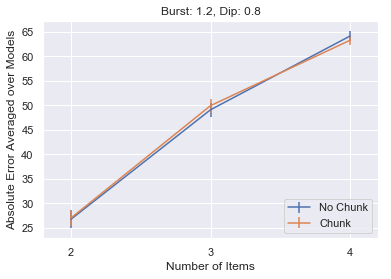

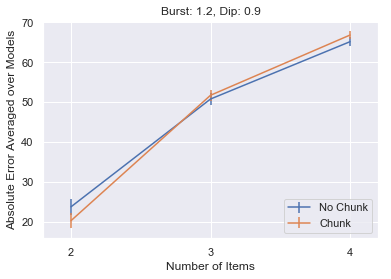

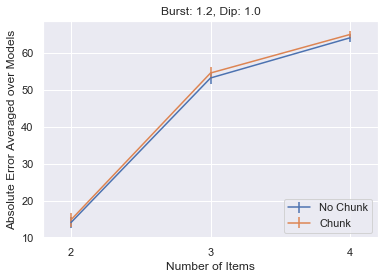

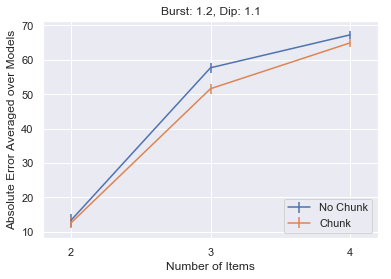

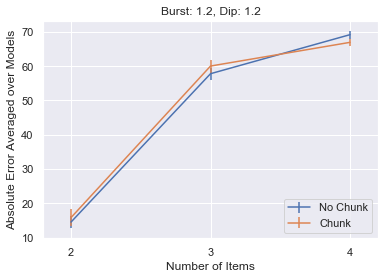

In [46]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/sigma12/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain
        print(experiment)
        burstdip_allmodels(base,base2,experiment, Burst[burst], Dip[dip])
        plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+".png")
        